In [1]:
import os
import re
import numpy as np
import pandas as pd
import json
import itertools

from math import pow,factorial,log,exp
from matplotlib import pyplot as plt, colors
from options_utility import parse_args, get_test_options, extract_arg_values
from workflow_parser import get_workflow, WorkflowIterator

In [34]:
def get_s(l: list) -> str:
    """
    Returns a string from a list of strings
    """
    return "[" + ','.join([str(i) for i in l]) + "]"

def PowerFact(b,e):
    """
    Returns b^e / e! used everywhere else in the model
    
    Parameters:
        b (int): base
        e (int): exponent
    """
    return pow(b,e) / factorial(e)

def erlangC(m,p):
    """
    Returns the probability a call waits.

    Parameters:
        m   (int): agent count
        p (float): lambda over (m times mu)
    """
    u = m * p
    suma = 0
    for k in range(0,m):
        suma += PowerFact(u,k)
    erlang = PowerFact(u,m) / ((PowerFact(u,m)) + (1-p)*suma)
    return erlang
    
def parse_jaeger_traces(file_path) -> tuple[pd.DataFrame, float, float]:
    """
    Parses a Jaeger JSON trace file to extract user-specific trace details
    and find the overall time range of the traces.

    Args:
        file_path (str): The path to the Jaeger JSON file.

    Returns:
        tuple: A tuple containing (processed_traces, overall_start_us, overall_end_us).
               - processed_traces (list): Traces with user_id, start, and end times.
               - overall_start_us (int): The earliest start time in microseconds.
               - overall_end_us (int): The latest end time in microseconds.
    """
    processed_traces = []
    overall_min_start_time_us = float('inf')
    overall_max_end_time_us = 0
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return [], 0, 0
    except json.JSONDecodeError:
        print(f"Error: The file '{file_path}' is not a valid JSON file.")
        return [], 0, 0

    if 'data' not in data or not isinstance(data['data'], list):
        print("Error: JSON file does not have the expected Jaeger format (missing 'data' array).")
        return [], 0, 0

    for trace in data['data']:
        user_id = None
        min_start_time = float('inf')
        max_end_time = 0

        if 'spans' not in trace or not trace['spans']:
            continue

        # Determine the absolute start and end time for this trace
        for span in trace['spans']:
            start_time = span.get('startTime', 0)
            duration = span.get('duration', 0)
            end_time = start_time + duration
            
            if start_time < min_start_time:
                min_start_time = start_time
            if end_time > max_end_time:
                max_end_time = end_time

        if min_start_time != float('inf'):
            processed_traces.append({
                'user_id': user_id,
                'duration': (max_end_time - min_start_time) // 1000,
                'start_time_us': min_start_time,
                'end_time_us': max_end_time
            })
            # Update overall min and max times
            if min_start_time < overall_min_start_time_us:
                overall_min_start_time_us = min_start_time
            if max_end_time > overall_max_end_time_us:
                overall_max_end_time_us = max_end_time

    return pd.DataFrame(processed_traces), overall_min_start_time_us, overall_max_end_time_us

def parse_metric_traces(file_path, metric_name="http_req_duration") -> tuple[pd.DataFrame, float, float]:
    """
    Parses a Jaeger JSON trace file to extract user-specific trace details
    and find the overall time range of the traces.

    Args:
        file_path (str): The path to the Jaeger JSON file.

    Returns:
        tuple: A tuple containing (processed_traces, overall_start_us, overall_end_us).
               - processed_traces (list): Traces with user_id, start, and end times.
               - overall_start_us (int): The earliest start time in microseconds.
               - overall_end_us (int): The latest end time in microseconds.
    """
    
    df = pd.read_csv(file_path)

    # Filtra solo le righe con la metrica http_req_duration
    durations = df[df["metric_name"] == metric_name].copy()

    # Calcola tempo di inizio e fine in microsecondi
    durations["start_time_us"] = durations["timestamp"] - durations['metric_value'].astype(int) * 1_000
    durations["end_time_us"] = (durations["timestamp"])

    # normalize by 0
    first = durations["start_time_us"].min()
    durations["start_time_us"] = durations["start_time_us"] - first
    durations["end_time_us"] = durations["end_time_us"] - first 

    # Seleziona colonne utili
    result = durations[["timestamp", "metric_value", "start_time_us", "group", "status", "end_time_us", "url", "scenario", "extra_tags", "metadata"]]
    result['extra_tags'] = result['extra_tags'].astype(str)

    return pd.DataFrame(result), result["start_time_us"].min(), result["end_time_us"].max()

def calculate_concurrency(traces, start_time_us: int, end_time_us: int, l = 1) -> pd.DataFrame:
    """
    Calculates the number of concurrent users for each second between
    the provided start and end times and returns a DataFrame.

    Returns:
        pd.DataFrame: with columns ['timestamp', 'concurrent_users']
                      where 'timestamp' is in seconds from simulation start.
    """
    timestamps = []
    concurrency_counts = []

    timestep_us = 1_000_000 // l  # 1 second in microsenconds, adjusted by the load factor l

    current_time_us = start_time_us + timestep_us // 2

    while current_time_us <= end_time_us:
        active_users = traces[(traces['start_time_us'] <= current_time_us) & (current_time_us < traces['end_time_us'])]        
        
        timestamps.append((current_time_us - start_time_us) // 1000)  # Convert microseconds to seconds
        concurrency_counts.append(len(active_users))

        current_time_us += timestep_us

    df = pd.DataFrame({
        'timestamp': timestamps,
        'concurrent_users': concurrency_counts
    })

    return df

def find_steady_state_start(diff_series, window=5, epsilon=0.5):
    for i in range(window, len(diff_series)):
        recent = diff_series.iloc[i-window:i].abs()
        if all(recent < epsilon):
            return i - window  # Index where steady state starts
    return None

def load_single_results(num_cores: list, mu: list, concurrent_users: int, iteration: int, metric_name: str = "http_req_duration", path: str = None) -> pd.DataFrame | None:
    folder_path = path
    # df = pd.json_normalize(dict['metrics'])
    df = pd.DataFrame()
    
    test_file = "report.csv"
    file_path = os.path.join(folder_path, test_file)
    spans = []

    if 'jaeger' in test_file:
        with open(file_path) as train_file:
            dict = json.load(train_file)
            spans = []
            for trace in dict['data']:
                for span in trace['spans']:
                    if re.match("GET /", span['operationName']):
                        spans.append(span)
            
            durations = pd.DataFrame([(span['duration'], span['processID']) for span in spans], columns=['duration', 'service'])
            mean_duration = durations.groupby('service')['duration'].mean().reset_index()

            #TODO: Separate by each load
            df = mean_duration
    else:
        df, start_us, end_us = parse_metric_traces(file_path, metric_name=metric_name)

    df['iteration'] = iteration

    return df

def load_results(options: dict[str, str], metric_name: str = "http_req_duration") -> pd.DataFrame:
    # Load the results.
    df = pd.DataFrame()

    core_combinations = [
        [ {"name": d["name"], "core": c} for d, c in zip(options["NODES"], combo) ]
        for combo in itertools.product(*(d["cores"] for d in options["NODES"]))
    ]

    for c in core_combinations:
        load_combinations = itertools.product(*(d["users"] if "users" in d else d["rate"] for d in options["LOAD"]["loads"]))

        for l in load_combinations:
            for i in range(options["LOAD"]['start'], options["LOAD"]['end']):
                it = WorkflowIterator(options["WORKFLOW"])
                for arg_comb in it:
                    flat_args = extract_arg_values(arg_comb)
                    f_path = os.path.join(options["RESULT_FOLDER"], "test", f"{get_s([d['core'] for d in c])}", get_s(l), str(get_s(flat_args)), str(i))
                    single_df = load_single_results([d["core"] for d in c], arg_comb, l, i, metric_name=metric_name, path=f_path)
                    # assign the right mu and cores from the num_core list and mu list
                    # the num cores depends on the index of the node name in the cores 
                    single_df['cores'] = single_df['extra_tags'].apply(lambda x: x.split('=')[1] if len(x.split('=')) > 1 else '0')
                    single_df['cores'] = single_df['cores'].apply(lambda x: next((item["core"] for item in c if item["name"] == x), None))
                    # the load depends on the value of the scenario tag
                    single_df['service_name'] = single_df['extra_tags'].apply(lambda x: x.split('=')[1] if len(x.split('=')) > 1 else 'all')

                    def _iter_leaf_nodes(node, path, prob=1.0):
                        if not isinstance(node, dict):
                            return
                        services = node.get("services")
                        node_type = node.get("type")
                        if services:
                            if node_type == "or" and len(services) == 2:
                                true_prob = node.get("probability", 0.5)
                                for idx, srv in enumerate(services):
                                    branch_prob = prob * (true_prob if idx == 0 else 1 - true_prob)
                                    yield from _iter_leaf_nodes(srv, path + (idx,), branch_prob)
                            else:
                                for idx, srv in enumerate(services):
                                    yield from _iter_leaf_nodes(srv, path + (idx,), prob)
                        else:
                            yield node, path, prob

                    leaf_lookup = {}
                    for scenario_idx in range(len(options["WORKFLOW"])):
                        wf_instance = arg_comb[scenario_idx] if scenario_idx < len(arg_comb) else options["WORKFLOW"][scenario_idx]
                        for leaf, path, prob in _iter_leaf_nodes(wf_instance, (scenario_idx,)):
                            values = leaf.get("arg_values")
                            value = values[0] if values else None
                            leaf_type = leaf.get("type")
                            leaf_lookup[path] = (value, leaf_type, prob)
                            node_name = leaf.get("node_name")
                            if node_name:
                                leaf_lookup[(scenario_idx, node_name)] = (value, leaf_type, prob)

                    def extract_leaf_info(row):
                        scenario_idx = int(row['scenario'].split('_')[2])
                        base_lambda = l[scenario_idx]
                        value, leaf_type, prob = leaf_lookup.get((scenario_idx, row['service_name']), (None, None, 1.0))
                        return base_lambda * prob, value, leaf_type

                    res = single_df.apply(extract_leaf_info, axis=1)
                    single_df['lambda'], single_df['mu'], single_df['service'] = zip(*res)
                    if single_df is not None:
                        #df = pd.concat([df, single_df, load_single_performance_recap([d["core"] for d in c], arg_comb, l, i, f_path)], ignore_index=True)
                        df = pd.concat([df, single_df], ignore_index=True)


    return df.fillna(0)

def is_outlier(s: pd.Series) -> pd.Series:
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    return (s < (Q1 - 1.5 * IQR)) | (s > (Q3 + 1.5 * IQR))

def load_single_performance_recap(num_cores: list, mu: list, concurrent_users: int, iteration: int, path: str = None) -> pd.DataFrame | None:
    if path is not None:
        folder_path = path
    else:
        folder_path = os.path.join(RESULT_FOLDER, "performance", f"{get_s(num_cores)}_core", str(get_s(mu)), f"{str(concurrent_users)}_users", str(iteration))
    
    file_path = os.path.join(folder_path, "metrics.json")
    with open(file_path) as train_file:
        dict = json.load(train_file)

    df = pd.json_normalize(dict['metrics'])

    rdf = pd.DataFrame({
        'timestamp': 0,
        'metric_value': df['iteration_duration.values.avg'],
        'start_time_us': 0,
        'end_time_us': 0,
        'metadata': 'service_name=all',
        'extra_tags': f'service_name=all',
        'iteration': iteration,
        'lambda': 0,
        'mu': 0,
        'scenario': 'all',
        'service': 'all',
        'service_name': 'all'
    })

    return rdf


In [33]:
notebook_folder = os.getcwd()
options = get_test_options(os.path.join(notebook_folder, 'base_complex_load', '3_seq_same'))
#options["LOAD"]["loads"][0]['users'][0] = 15
print(options)
test_result = load_results(options)
remove_outliers = False
if remove_outliers:
    test_result = test_result[~is_outlier(test_result['metric_value'])]
test_result

{'RESULT_FOLDER': '/mnt/s/Projects/qesm/docker-workflows-experimentation/tests/k6/base_complex_load/3_seq_same', 'TEST_SERVICE': '3_seq_same', 'TEST_PATH': '/mnt/s/Projects/qesm/docker-workflows-experimentation/tests/k6', 'WORKFLOW': [{'node_name': 'first', 'type': 'sequential', 'services': [{'node_name': 'first', 'type': 'exponentialop', 'arg_name': 'max', 'arg_values': [50000000]}, {'node_name': 'second', 'type': 'exponentialop', 'arg_name': 'max', 'arg_values': [25000000]}, {'node_name': 'third', 'type': 'exponentialop', 'arg_name': 'max', 'arg_values': [25000000]}]}, {'node_name': 'second', 'type': 'exponentialop', 'arg_name': 'max', 'arg_values': [25000000]}], 'LOAD': {'start': 1, 'end': 21, 'loads': [{'type': 'closed_loop', 'users': [5]}, {'type': 'closed_loop', 'users': [9]}]}, 'NODES': [{'name': 'first', 'cores': [3]}, {'name': 'second', 'cores': [2]}, {'name': 'third', 'cores': [3]}]}


/tmp/ipykernel_1736/3788392281.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['extra_tags'] = result['extra_tags'].astype(str)
/tmp/ipykernel_1736/3788392281.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['extra_tags'] = result['extra_tags'].astype(str)
/tmp/ipykernel_1736/3788392281.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

,timestamp,metric_value,start_time_us,group,status,end_time_us,url,scenario,extra_tags,metadata,iteration,cores,service_name,lambda,mu,service
0,1760362029710273,54.666326,768,0.0,200.0,54768,http://localhost:8081/service/exponentialop?ma...,closed_loop_1,service_name=second,trace_id=dc0718186e0ff06d9cc2bd42215a8634,1,2,second,9.0,25000000,exponentialop
1,1760362030289357,633.845245,852,0.0,200.0,633852,http://localhost:8081/service/exponentialop?ma...,closed_loop_1,service_name=second,trace_id=dc0718186e0ff06d9cc2f8703c9a895c,1,2,second,9.0,25000000,exponentialop
2,1760362030349592,694.197374,87,0.0,200.0,694087,http://localhost:8080/service/exponentialop?ma...,closed_loop_0,service_name=first,trace_id=dc0718186e0ff06d8d7f5dac784d6010,1,3,first,5.0,50000000,exponentialop
3,1760362030379956,669.056047,55451,0.0,200.0,724451,http://localhost:8081/service/exponentialop?ma...,closed_loop_1,service_name=second,trace_id=dc0718186e0ff070f340a24a313602d2,1,2,second,9.0,25000000,exponentialop
4,1760362030387168,731.589167,663,0.0,200.0,731663,http://localhost:8080/service/exponentialop?ma...,closed_loop_0,service_name=first,trace_id=dc0718186e0ff06d8d7fb1493d5482f1,1,3,first,5.0,50000000,exponentialop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21198,1760362344094676,497.236468,14826993,0.0,200.0,15323993,http://localhost:8081/service/exponentialop?ma...,closed_loop_1,service_name=second,trace_id=dc0718186e10398612c5b7b5cd3c840e,20,2,second,9.0,25000000,exponentialop
21199,1760362344098214,558.914298,14769531,0.0,200.0,15327531,http://localhost:8081/service/exponentialop?ma...,closed_loop_1,service_name=second,trace_id=dc0718186e1039829dc3f9d8922c4b05,20,2,second,9.0,25000000,exponentialop
21200,1760362344136414,397.010653,14968731,0.0,200.0,15365731,http://localhost:8080/service/exponentialop?ma...,closed_loop_0,service_name=first,trace_id=dc0718186e10398e898507d05f6fb567,20,3,first,5.0,50000000,exponentialop
21201,1760362344215506,78.800478,15366823,0.0,200.0,15444823,http://localhost:8081/service/exponentialop?ma...,closed_loop_0,service_name=second,trace_id=dc0718186e1039a63342b619279c4cfe,20,2,second,5.0,25000000,exponentialop


In [35]:
iteration_results = load_results(options, metric_name="iteration_duration")
iteration_results

/tmp/ipykernel_1736/3788392281.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['extra_tags'] = result['extra_tags'].astype(str)
/tmp/ipykernel_1736/3788392281.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['extra_tags'] = result['extra_tags'].astype(str)
/tmp/ipykernel_1736/3788392281.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

,timestamp,metric_value,start_time_us,group,status,end_time_us,url,scenario,extra_tags,metadata,iteration,cores,service_name,lambda,mu,service
0,1760362029710531,56.125394,1155,0.0,0.0,57155,0,closed_loop_1,nan,0,1,0,all,9.0,0,0
1,1760362030289521,634.862569,2145,0.0,0.0,636145,0,closed_loop_1,nan,0,1,0,all,9.0,0,0
2,1760362030380022,669.459576,57646,0.0,0.0,726646,0,closed_loop_1,nan,0,1,0,all,9.0,0,0
3,1760362030743908,1090.077104,532,0.0,0.0,1090532,0,closed_loop_1,nan,0,1,0,all,9.0,0,0
4,1760362030822968,1169.704762,592,0.0,0.0,1169592,0,closed_loop_1,nan,0,1,0,all,9.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13252,1760362344060542,317.243056,14974749,0.0,0.0,15291749,0,closed_loop_1,nan,0,20,0,all,9.0,0,0
13253,1760362344074978,797.082712,14509185,0.0,0.0,15306185,0,closed_loop_1,nan,0,20,0,all,9.0,0,0
13254,1760362344094720,497.524280,14828927,0.0,0.0,15325927,0,closed_loop_1,nan,0,20,0,all,9.0,0,0
13255,1760362344098255,559.198241,14770462,0.0,0.0,15329462,0,closed_loop_1,nan,0,20,0,all,9.0,0,0


In [36]:
# per ogni servizio di ogni scenario, calcola il tempo e2e teorico, dalla media dei dati
def compute_mean_service_time(all_data: pd.DataFrame) -> pd.DataFrame:
    """
    Calcola il tempo medio di servizio (metric_value) per ogni run, scenario e servizio.
    """
    if all_data.empty:
        print("DataFrame vuoto: impossibile calcolare i tempi medi di servizio.")
        return pd.DataFrame(columns=["iteration", "scenario", "service", "mean_service_time_ms"])

    df = all_data[["iteration", "scenario", "service_name", "service", "extra_tags", "metric_value", "mu"]].copy()
    df["metric_value"] = pd.to_numeric(df["metric_value"], errors="coerce")
    df.dropna(subset=["metric_value"], inplace=True)

    result = (
        df.groupby(["scenario", "service_name", "service", "mu"], dropna=False)["metric_value"]
        .mean()
        .reset_index()
        .rename(columns={"metric_value": "mean_service_time_ms"})
        .sort_values(["scenario", "service_name", "service"])
        .reset_index(drop=True)
    )

    return result

mean_service_times = compute_mean_service_time(test_result)
mean_service_times

,scenario,service_name,service,mu,mean_service_time_ms
0,closed_loop_0,first,exponentialop,50000000,86.875629
1,closed_loop_0,second,exponentialop,25000000,251.208079
2,closed_loop_0,third,exponentialop,25000000,43.328789
3,closed_loop_1,second,exponentialop,25000000,293.757526


/tmp/ipykernel_1736/4138207326.py:91: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  scenario_totals = mean_user_counts.groupby(level='scenario', axis=1).sum()


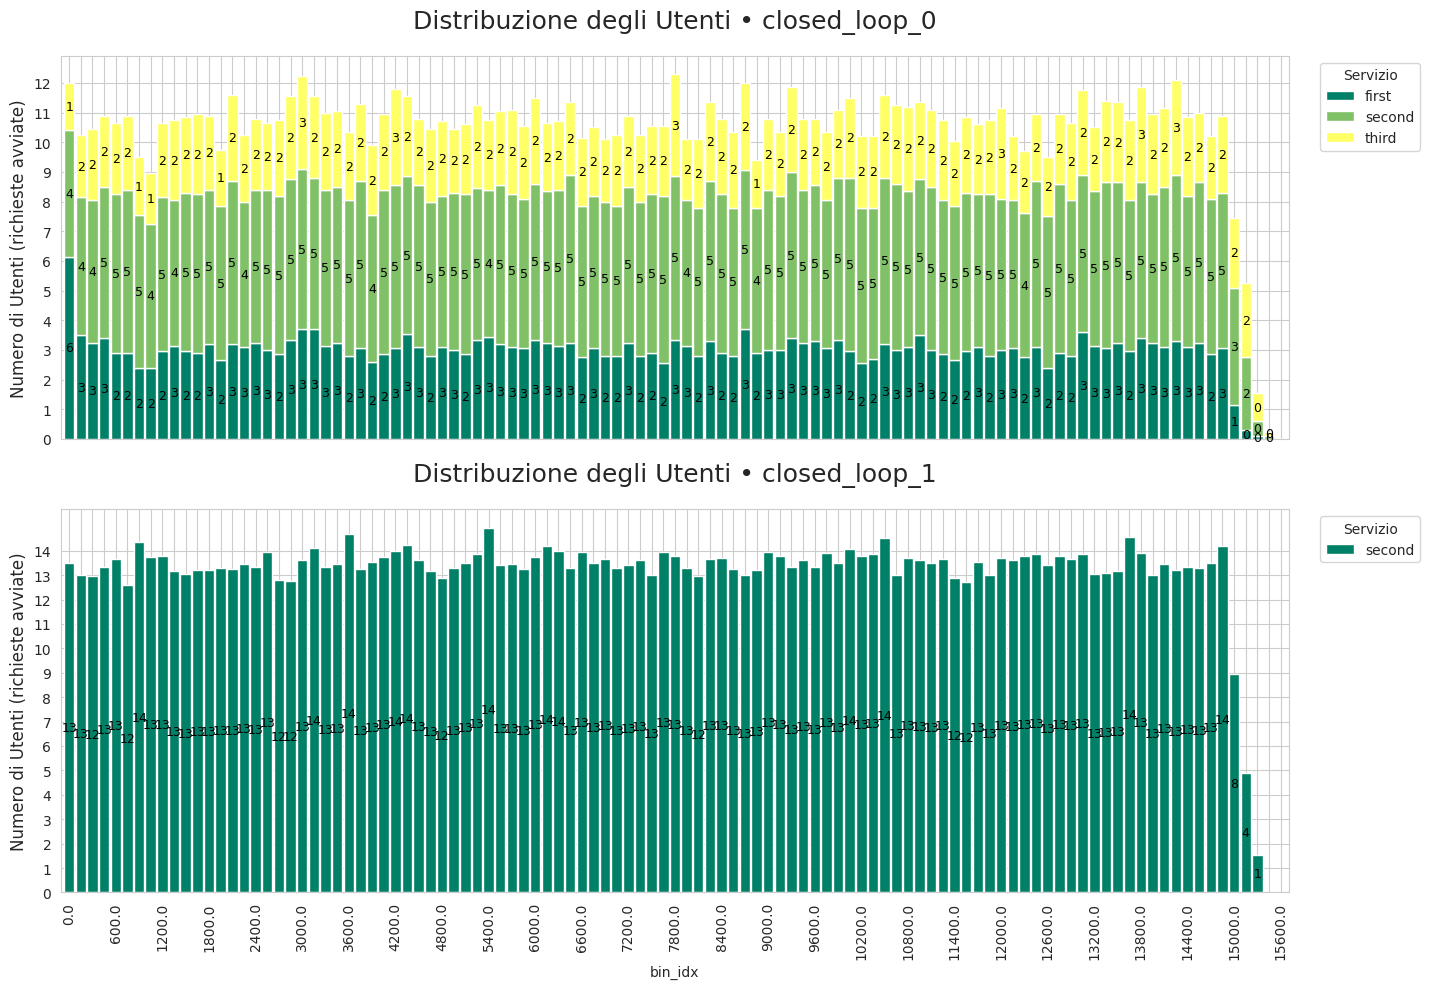

scenario       service
closed_loop_0  first       2.957143
               second      5.063333
closed_loop_1  second     13.030952
closed_loop_0  third       2.418571
dtype: float64

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.ticker import MultipleLocator

def parse_service_name(extra_tags_str: str) -> str:
    """
    Estrae il valore di 'service_name' dalla stringa extra_tags.
    Esempio: 'service_name=first,trace_id=...' -> 'first'
    """
    try:
        # Divide la stringa in base alle virgole e cerca il pezzo con 'service_name'
        for part in extra_tags_str.split(','):
            if 'service_name=' in part:
                return part.split('=')[1]
    except (TypeError, AttributeError):
        # Ritorna 'sconosciuto' se il campo è vuoto o non è una stringa
        return 'sconosciuto'
    return 'sconosciuto'

def create_user_load_plot(all_data: pd.DataFrame, time_step_ms: int = 500):
    """
    Carica i dati da una lista di file CSV, li elabora e crea un grafico
    a barre sovrapposte del carico di utenti nel tempo.

    Args:
        csv_files (list): Una lista di percorsi ai file CSV da analizzare.
        time_step_ms (int): L'ampiezza dell'intervallo di tempo in millisecondi.
    """
    requests_df = all_data[all_data['scenario'] != 'all'].copy()

    if requests_df.empty:
        print("Non sono state trovate metriche 'http_reqs' nei file. Impossibile generare il grafico.")
        return

    bin_width_us = time_step_ms * 1000

    requests_df['service'] = requests_df['extra_tags'].apply(parse_service_name)
    requests_df['segment'] = requests_df['service'] + ' • ' + requests_df['scenario']
    requests_df['start_bin_idx'] = (requests_df['start_time_us'] // bin_width_us).astype(int)
    requests_df['end_bin_idx'] = (
        (np.maximum(requests_df['end_time_us'] - 1, requests_df['start_time_us'])) // bin_width_us
    ).astype(int)

    start_events = (
        requests_df.groupby(['iteration', 'segment', 'start_bin_idx'])
        .size()
        .rename('delta')
        .reset_index()
        .rename(columns={'start_bin_idx': 'bin_idx'})
    )
    end_events = (
        requests_df.groupby(['iteration', 'segment', 'end_bin_idx'])
        .size()
        .rename('delta')
        .reset_index()
        .rename(columns={'end_bin_idx': 'bin_idx'})
    )
    end_events['bin_idx'] += 1
    end_events['delta'] = -end_events['delta']

    events = pd.concat([start_events, end_events], ignore_index=True)
    events['bin_idx'] = events['bin_idx'].astype(int)
    changes = events.pivot_table(index=['iteration', 'bin_idx'], columns='segment', values='delta', aggfunc='sum', fill_value=0)

    min_bin = int(requests_df['start_bin_idx'].min())
    max_bin = int(requests_df['end_bin_idx'].max()) + 1
    iterations = sorted(requests_df['iteration'].unique())
    full_index = pd.MultiIndex.from_product([iterations, range(min_bin, max_bin + 1)], names=['iteration', 'bin_idx'])
    changes = changes.reindex(full_index, fill_value=0)

    user_counts = changes.groupby(level='iteration').cumsum()
    mean_user_counts = user_counts.groupby(level='bin_idx').mean()
    if mean_user_counts.empty:
        print("Impossibile calcolare la media delle richieste attive.")
        return
    mean_user_counts.index = mean_user_counts.index.astype(int) * time_step_ms

    column_tuples = []
    for seg in mean_user_counts.columns:
        parts = seg.split(' • ', 1)
        if len(parts) == 2:
            service, scenario = parts
        else:
            service, scenario = seg, 'sconosciuto'
        column_tuples.append((scenario.strip(), service.strip()))
    mean_user_counts.columns = pd.MultiIndex.from_tuples(column_tuples, names=['scenario', 'service'])

    scenarios = list(mean_user_counts.columns.levels[0])
    scenario_totals = mean_user_counts.groupby(level='scenario', axis=1).sum()

    sns.set_style("whitegrid")
    num_plots = len(scenarios)
    fig, axes = plt.subplots(num_plots, 1, figsize=(16, 6 * num_plots), sharex=True)
    if num_plots == 1:
        axes = [axes]

    def handle_x_ticks(ax, stacked=True):
        num_ticks = len(ax.get_xticklabels())
        if num_ticks > 50:
            tick_spacing = max(1, num_ticks // 25)
            for i, label in enumerate(ax.get_xticklabels()):
                if i % tick_spacing != 0:
                    label.set_visible(False)

        if stacked:
            for container in ax.containers:
                labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
                ax.bar_label(container, labels=labels, label_type='center', color='black', fontsize=9)

    for idx, scenario in enumerate(scenarios):
        ax = axes[idx]
        scenario_data = mean_user_counts.xs(scenario, axis=1)
        scenario_data.plot(
            kind='bar',
            stacked=True,
            figsize=(16, 10),
            width=0.9,
            ax=ax,
            colormap='summer'
        )
        ax.set_title(f"Distribuzione degli Utenti • {scenario}", fontsize=18, pad=20)
        ax.set_ylabel('Numero di Utenti (richieste avviate)', fontsize=12)
        ax.legend(title='Servizio', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.set_yticks(range(0, int(scenario_totals[scenario].max()) + 1, 1))
        handle_x_ticks(ax, stacked=True)
        if idx < num_plots - 1:
            ax.tick_params(labelbottom=False)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

    return mean_user_counts

# Chiama la funzione per creare il grafico
mean_user_counts = create_user_load_plot(test_result, 0.15 * 1_000)
mean_user_counts.mean()

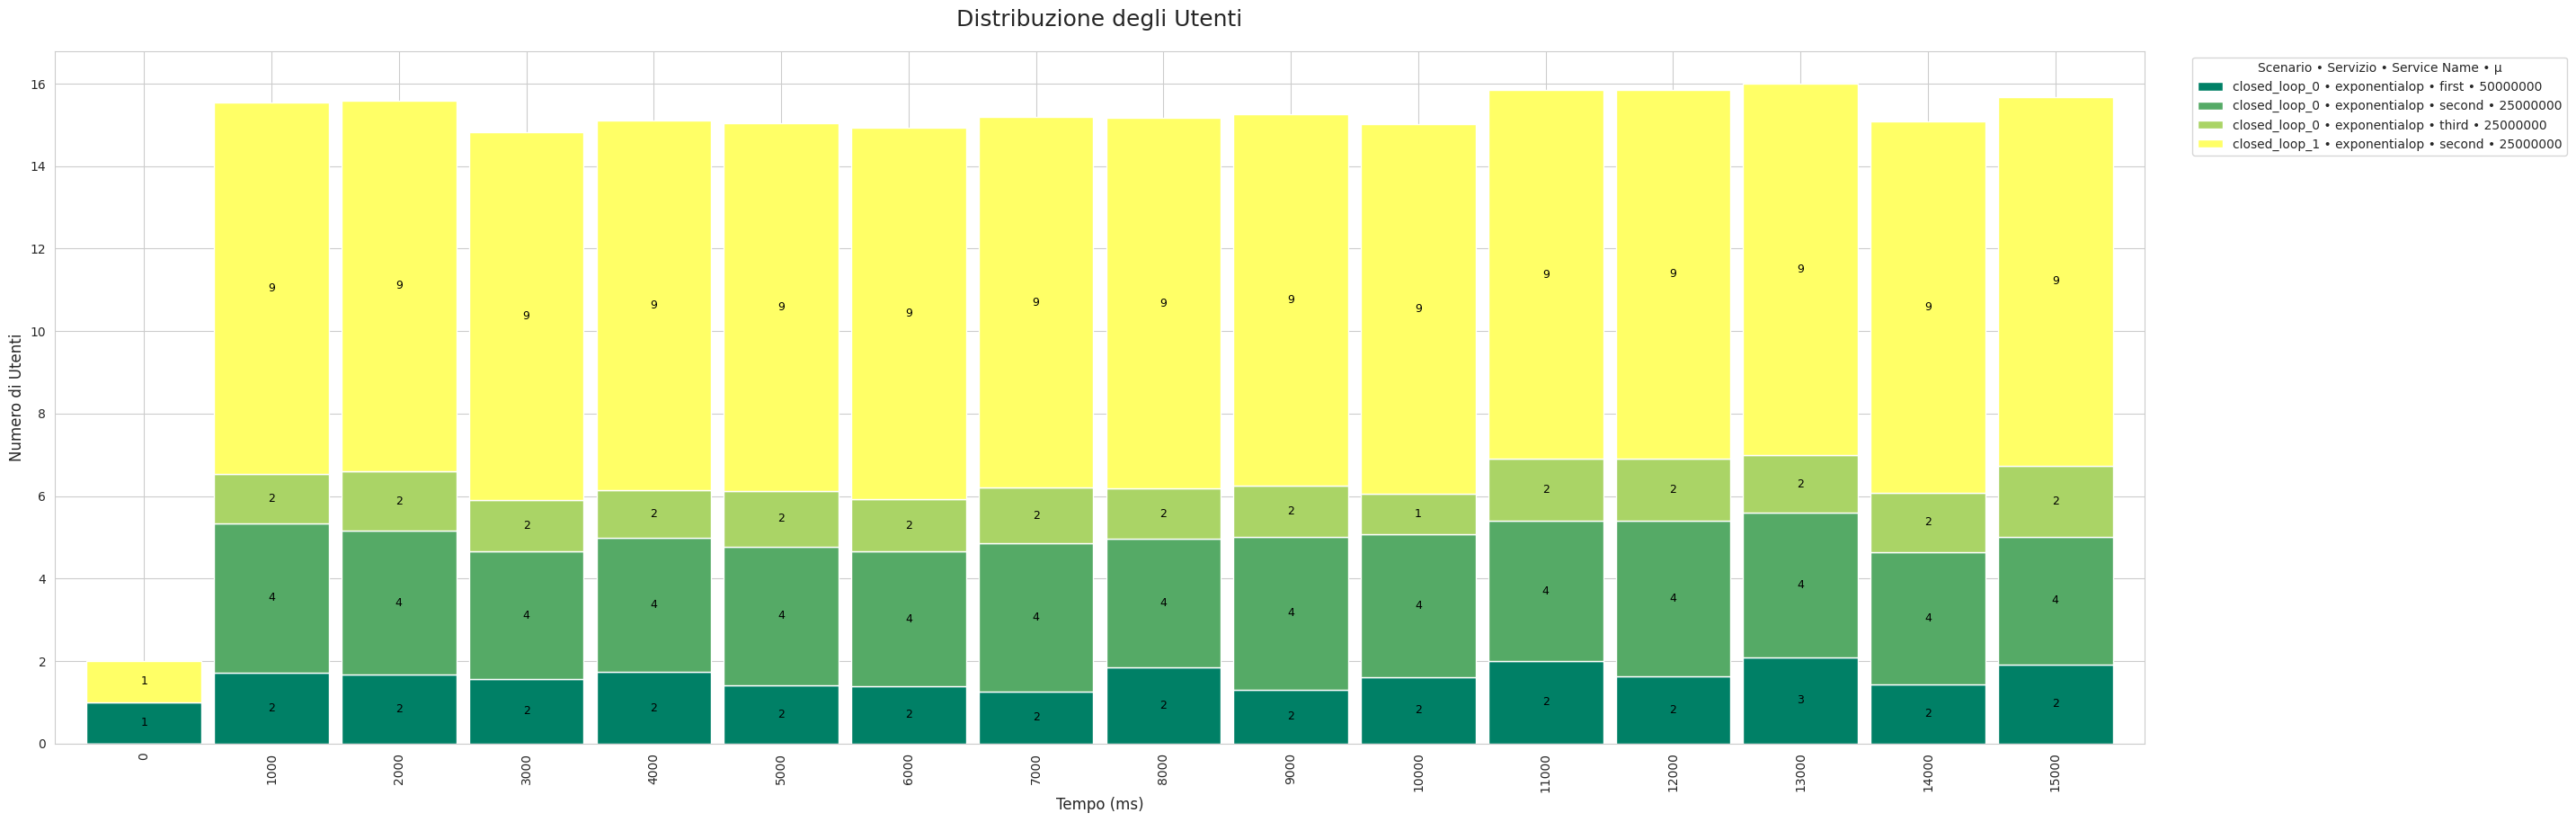

,timestamp,service,scenario,service_name,mu,users
0,0,exponentialop,closed_loop_0,first,50000000,1.000000
1,0,exponentialop,closed_loop_1,second,25000000,1.000000
2,1000000,exponentialop,closed_loop_0,first,50000000,1.714286
3,1000000,exponentialop,closed_loop_0,second,25000000,3.631579
4,1000000,exponentialop,closed_loop_0,third,25000000,1.200000
...,...,...,...,...,...,...
57,14000000,exponentialop,closed_loop_1,second,25000000,9.000000
58,15000000,exponentialop,closed_loop_0,first,50000000,1.916667
59,15000000,exponentialop,closed_loop_0,second,25000000,3.100000
60,15000000,exponentialop,closed_loop_0,third,25000000,1.714286


In [38]:
import math

def sample_users(all_data: pd.DataFrame, sample_time_us: int = 500000) -> pd.DataFrame:
    if all_data is None or all_data.empty:
        return pd.DataFrame(columns=['timestamp', 'service', 'scenario', 'service_name', 'mu', 'users'])

    # Ensure necessary columns exist
    requests_df = all_data.copy()
    if 'service' not in requests_df.columns:
        requests_df['service'] = requests_df['extra_tags'].apply(parse_service_name)
    if 'service_name' not in requests_df.columns:
        requests_df['service_name'] = requests_df['extra_tags'].apply(parse_service_name)
    if 'mu' not in requests_df.columns:
        requests_df['mu'] = requests_df.get('mu', np.nan)

    max_time_us = int(requests_df['end_time_us'].max())
    time_points = range(0, max_time_us + sample_time_us, sample_time_us)

    records = []
    for t in time_points:
        active = requests_df[(requests_df['start_time_us'] <= t) & (t < requests_df['end_time_us'])]
        if active.empty:
            # optionally include zero rows for known service/scenario combos if desired
            continue

        # compute per-iteration concurrent counts, then average across iterations
        per_iter_counts = (
            active
            .groupby(['iteration', 'service', 'scenario', 'service_name', 'mu'])
            .size()
            .reset_index(name='count')
        )

        mean_counts = (
            per_iter_counts
            .groupby(['service', 'scenario', 'service_name', 'mu'], dropna=False)['count']
            .mean()
            .reset_index()
            .rename(columns={'count': 'users'})
        )

        mean_counts['timestamp'] = t
        # keep desired column order
        mean_counts = mean_counts[['timestamp', 'service', 'scenario', 'service_name', 'mu', 'users']]
        records.append(mean_counts)

    if not records:
        return pd.DataFrame(columns=['timestamp', 'service', 'scenario', 'service_name', 'mu', 'users'])

    result = pd.concat(records, ignore_index=True)
    # users is an average across iterations; keep float (or round/ceil as needed downstream)
    result['users'] = result['users'].astype(float)

    return result

def plot_sampled_users(sampled_df: pd.DataFrame):
    if sampled_df.empty:
        print("Nessun dato campionato disponibile per il grafico.")
        return

    df = sampled_df.copy()
    df['timestamp_ms'] = (df['timestamp'] // 1000).astype(int)

    pivot = df.pivot_table(
        index='timestamp_ms',
        columns=['scenario', 'service', 'service_name', 'mu'],
        values='users',
        aggfunc='mean',
        fill_value=0
    )

    if pivot.empty:
        print("Impossibile aggregare i dati campionati per il grafico.")
        return

    pivot.columns = [' • '.join(map(str, col)) for col in pivot.columns]
    sns.set_style("whitegrid")
    ax = pivot.plot(
        kind='bar',
        stacked=True,
        width=0.9,
        colormap='summer',
        figsize=(30, 10)
    )

    ax.set_title("Distribuzione degli Utenti", fontsize=18, pad=20)
    ax.set_xlabel("Tempo (ms)", fontsize=12)
    ax.set_ylabel("Numero di Utenti", fontsize=12)
    ax.legend(title='Scenario • Servizio • Service Name • μ', bbox_to_anchor=(1.02, 1), loc='upper left')

    num_ticks = len(ax.get_xticklabels())
    if num_ticks > 50:
        tick_spacing = max(1, num_ticks // 10)
        for i, label in enumerate(ax.get_xticklabels()):
            if i % tick_spacing != 0:
                label.set_visible(False)

    for container in ax.containers:
        labels = [f"{math.ceil(v)}" if v > 0 else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', color='black', fontsize=9)

    #plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

sampled_users = sample_users(test_result, 10 * 100_000)
plot_sampled_users(sampled_users)
sampled_users

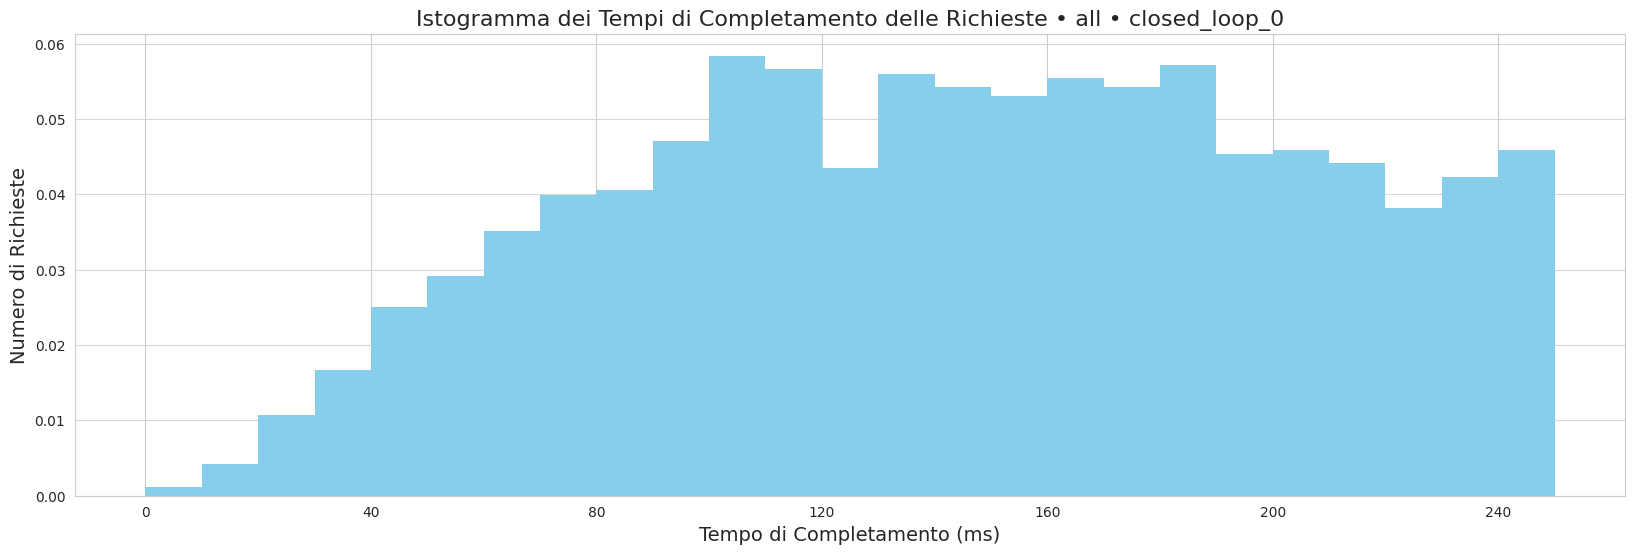

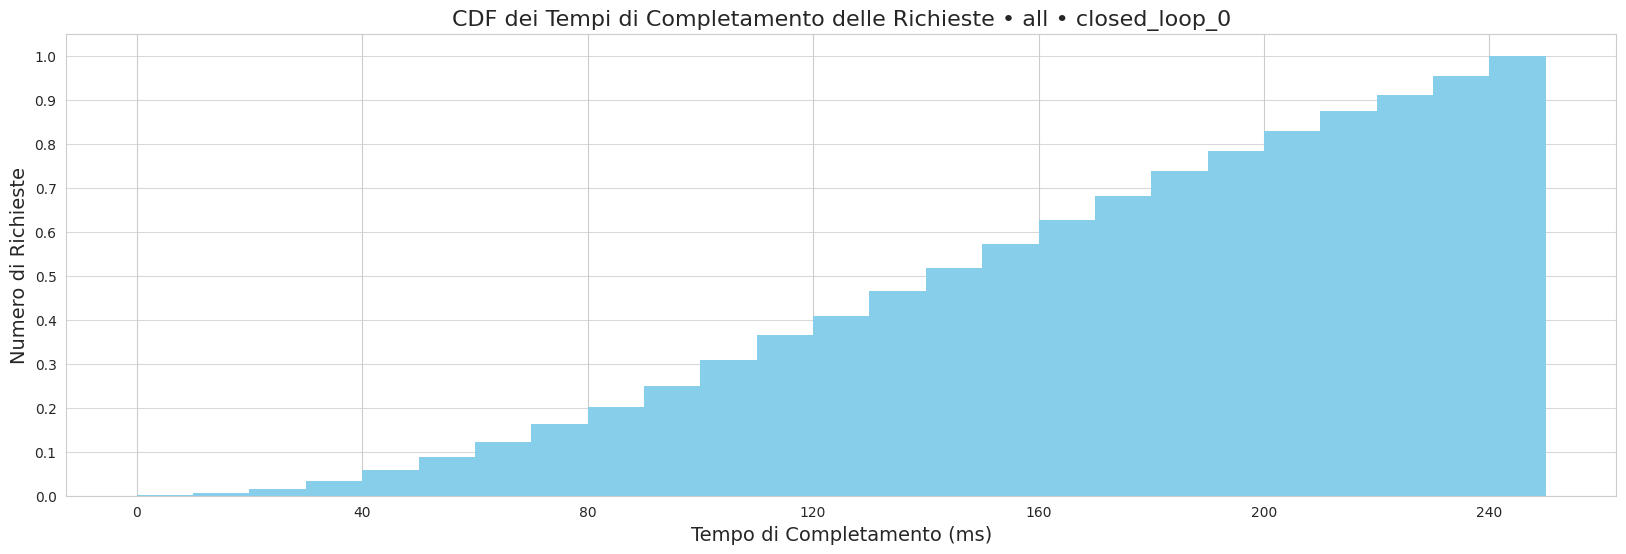

Media tempi di completamento per all • closed_loop_0: 382.4670638441983 ms
CDF: 0.00, 0.01, 0.02, 0.03, 0.06, 0.09, 0.12, 0.16, 0.20, 0.25, 0.31, 0.36, 0.41, 0.46, 0.52, 0.57, 0.63, 0.68, 0.74, 0.78, 0.83, 0.87, 0.91, 0.95, 1.00


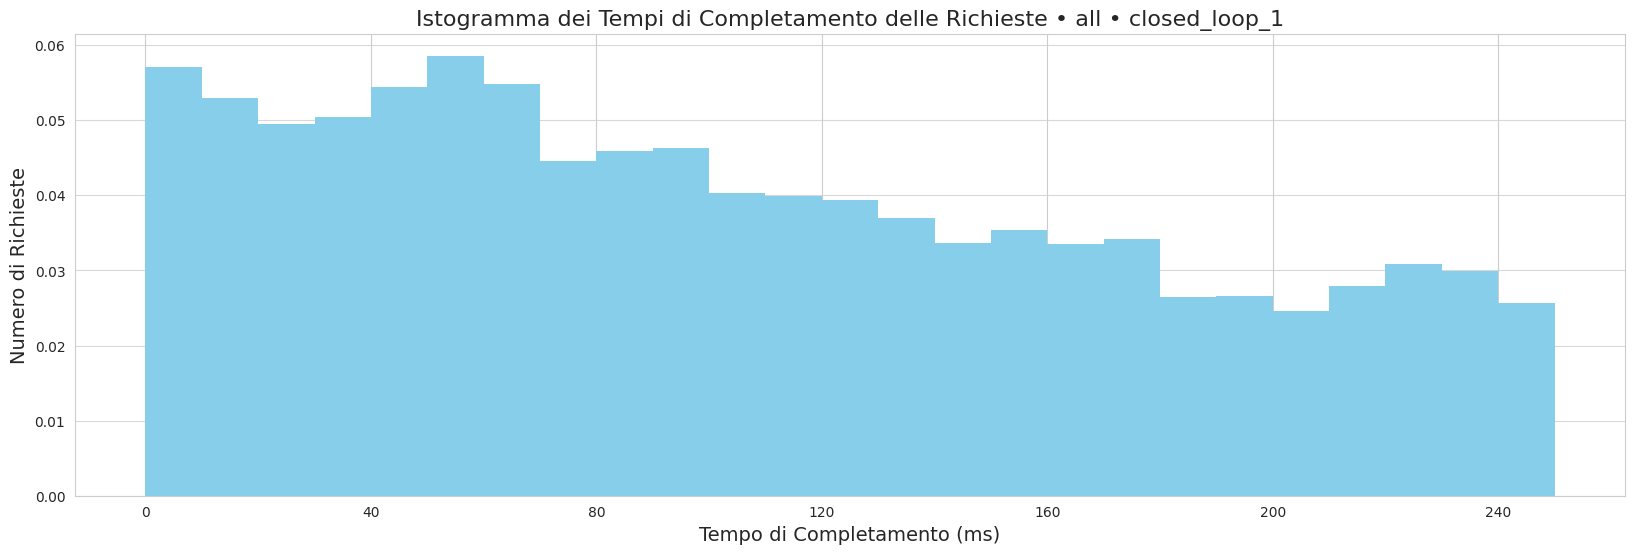

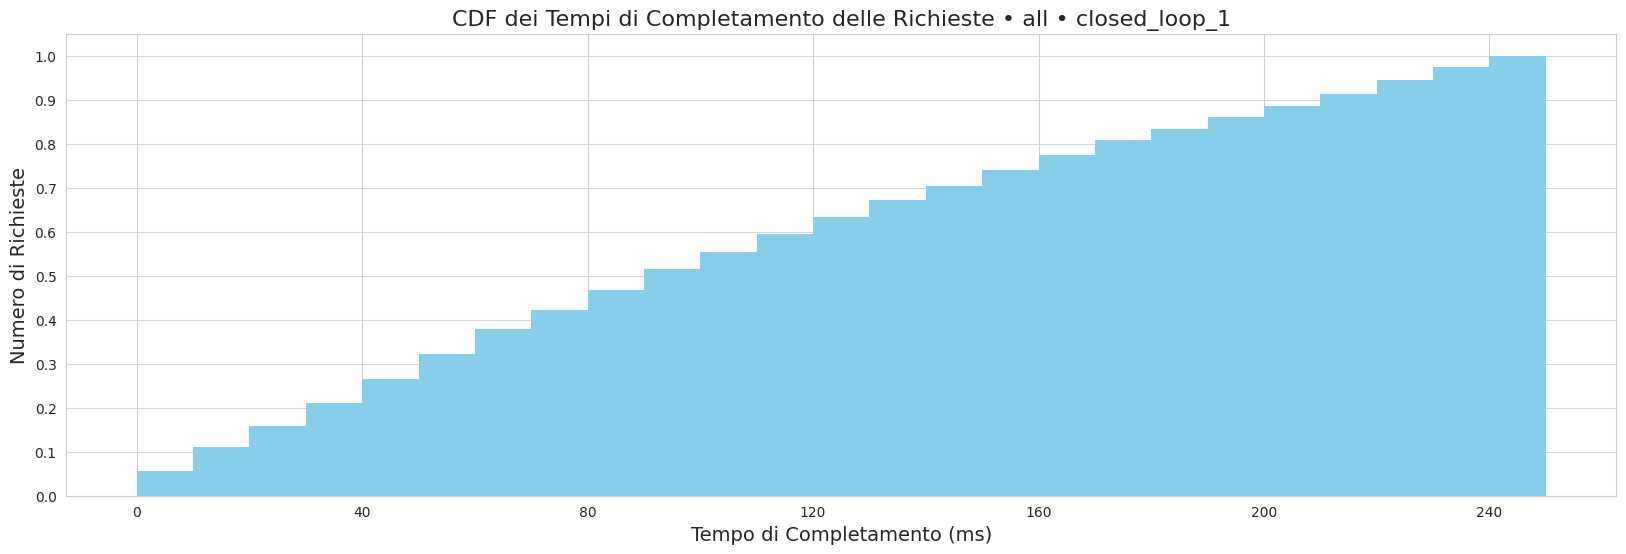

Media tempi di completamento per all • closed_loop_1: 294.1491223082723 ms
CDF: 0.06, 0.11, 0.16, 0.21, 0.26, 0.32, 0.38, 0.42, 0.47, 0.51, 0.56, 0.59, 0.63, 0.67, 0.70, 0.74, 0.77, 0.81, 0.83, 0.86, 0.89, 0.91, 0.94, 0.97, 1.00


nan

In [39]:
time_tick_ms = 10
time_limit_ms = 250

def histogram_completion_times_full(all_data: pd.DataFrame, all=False, tick_ms: int = 100, time_limit_ms: int = None):
    """
    Crea un istogramma dei tempi di completamento delle richieste.

    Args:
        all_data (pd.DataFrame): DataFrame contenente i dati delle richieste.
        bin_size_ms (int): Dimensione del bin in millisecondi.
    """
    if 'metric_value' not in all_data.columns:
        print("La colonna 'metric_value' non è presente nei dati.")
        return

    # get rid of outliers
    # completion_times_ms = all_data['metric_value']
    # calc the histogram

    # plot the histogram of each scenario-service couple
    for (scenario, service), group in all_data.groupby(['scenario', 'service_name']):
        if not all and (service == 'all' or scenario != 'all') and (scenario == 'all' and service == 'all'):
            continue

        times = group['metric_value']
        if times.empty:
            continue
        count, bins = np.histogram(times, bins=range(0, int(times.max() if not time_limit_ms else time_limit_ms) + tick_ms, tick_ms))
        plt.figure(figsize=(20, 6))
        plt.stairs(count / count.sum(), bins, color='skyblue', fill=True)
        plt.title(f"Istogramma dei Tempi di Completamento delle Richieste • {service} • {scenario}", fontsize=16)
        plt.xlabel("Tempo di Completamento (ms)", fontsize=14)
        plt.ylabel("Numero di Richieste", fontsize=14)
        plt.gca().xaxis.set_major_locator(MultipleLocator(tick_ms * 4, ))
        plt.grid(axis='y', alpha=0.75)
        plt.show()
        plt.close()

        # and now the cdf
        cdf = np.cumsum(count) / count.sum()
        plt.figure(figsize=(20, 6))
        plt.stairs(cdf, bins, color='skyblue', fill=True)
        plt.title(f"CDF dei Tempi di Completamento delle Richieste • {service} • {scenario}", fontsize=16)
        plt.xlabel("Tempo di Completamento (ms)", fontsize=14)
        plt.ylabel("Numero di Richieste", fontsize=14)
        plt.yticks(np.arange(0, 1.1, 0.1))
        plt.gca().xaxis.set_major_locator(MultipleLocator(tick_ms * 4))
        plt.grid(axis='y', alpha=0.75)
        plt.show()
        plt.close()

        print(f"Media tempi di completamento per {service} • {scenario}: {times.mean()} ms")
        print(f"CDF: " + ", ".join([f"{cdf[i]:.2f}" for i in range(len(cdf))]))

histogram_completion_times_full(iteration_results, False, time_tick_ms, time_limit_ms)
iteration_results[iteration_results['scenario'] == 'all']['metric_value'].mean()

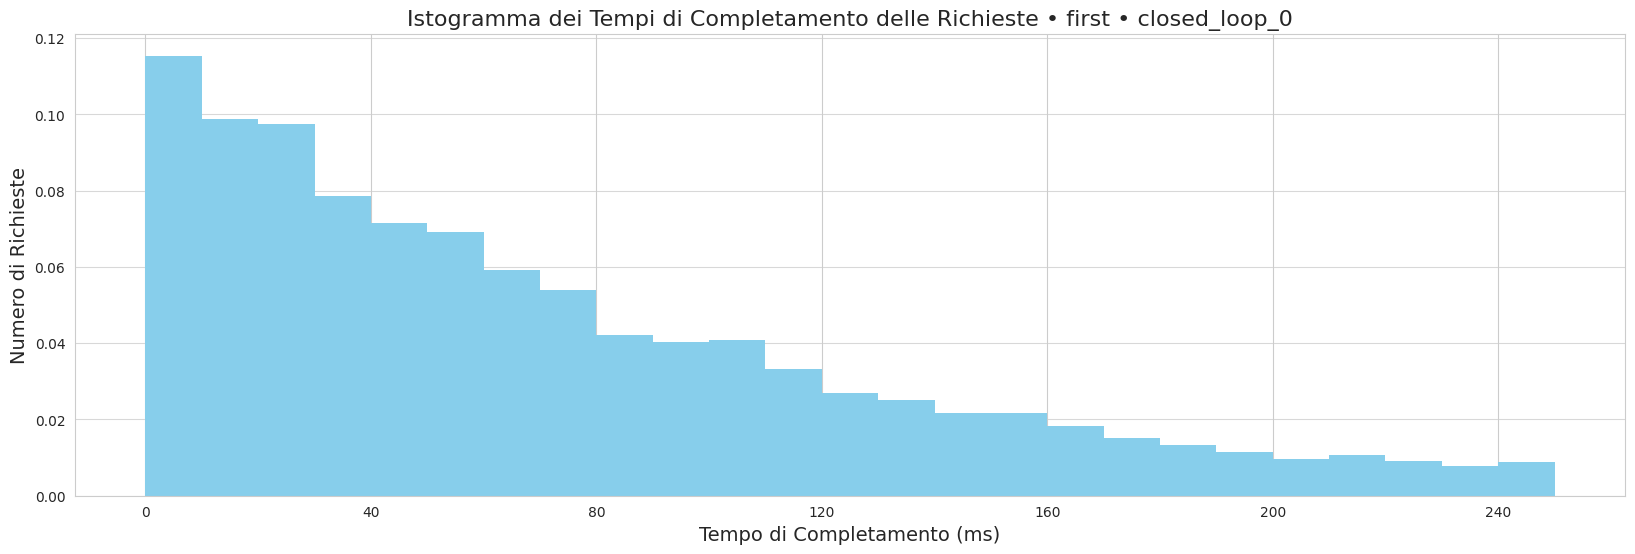

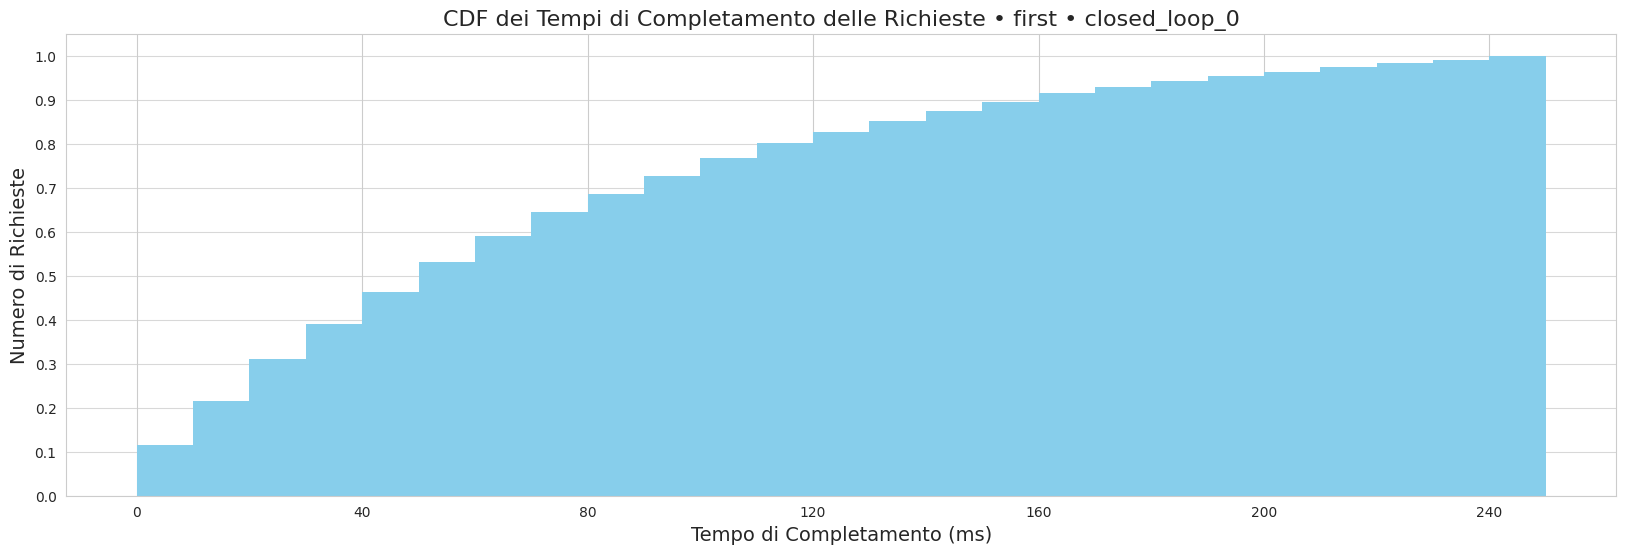

Media tempi di completamento per first • closed_loop_0: 86.87562916234583 ms
CDF: 0.12, 0.21, 0.31, 0.39, 0.46, 0.53, 0.59, 0.64, 0.69, 0.73, 0.77, 0.80, 0.83, 0.85, 0.87, 0.90, 0.91, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.00


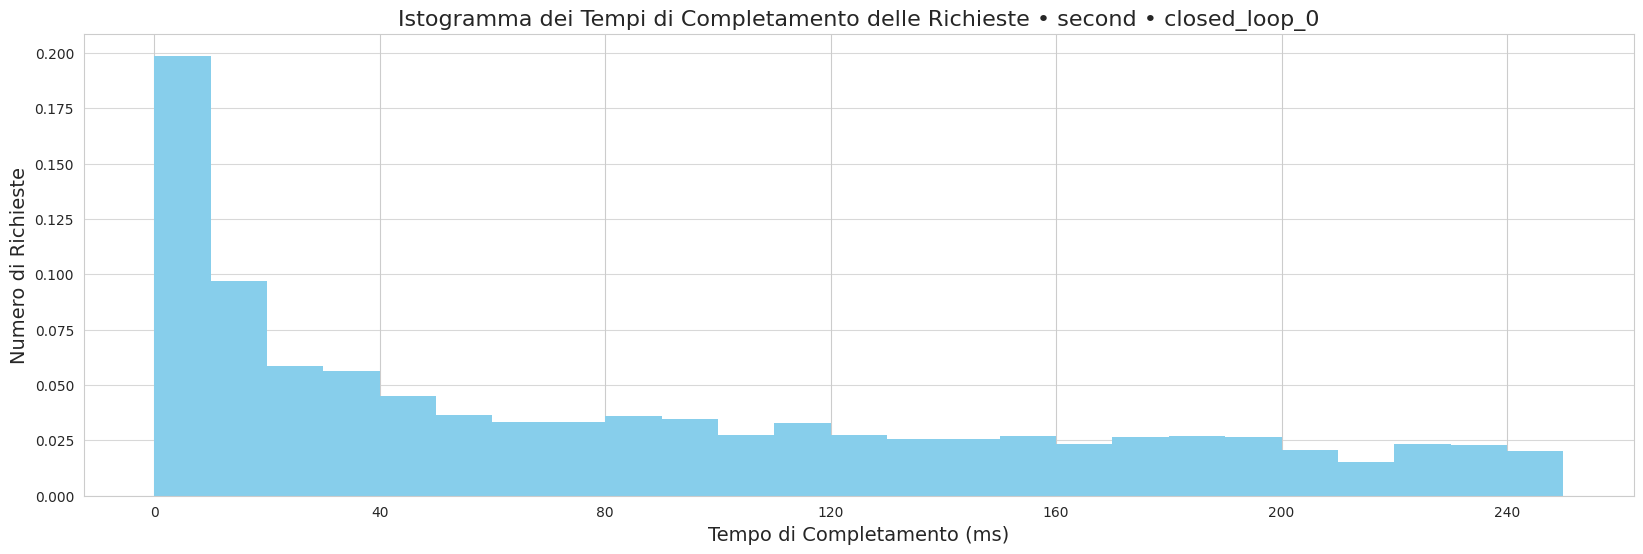

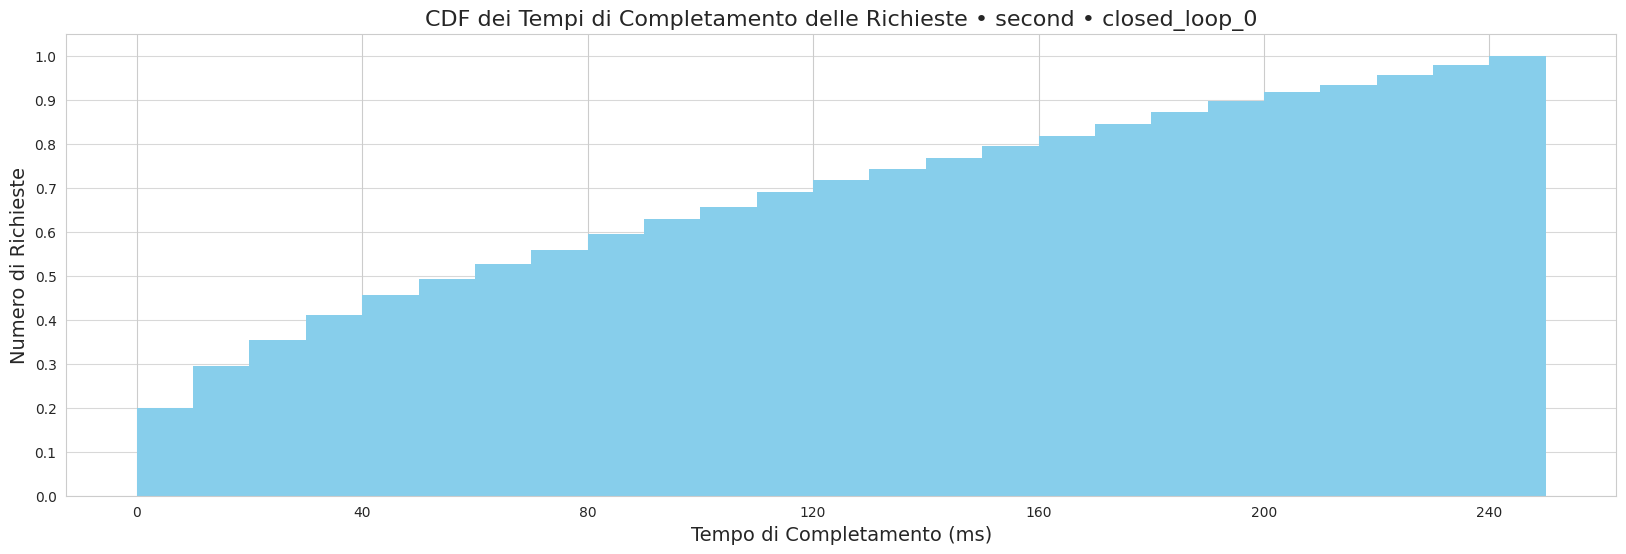

Media tempi di completamento per second • closed_loop_0: 251.20807910495844 ms
CDF: 0.20, 0.30, 0.35, 0.41, 0.46, 0.49, 0.53, 0.56, 0.59, 0.63, 0.66, 0.69, 0.72, 0.74, 0.77, 0.80, 0.82, 0.84, 0.87, 0.90, 0.92, 0.93, 0.96, 0.98, 1.00


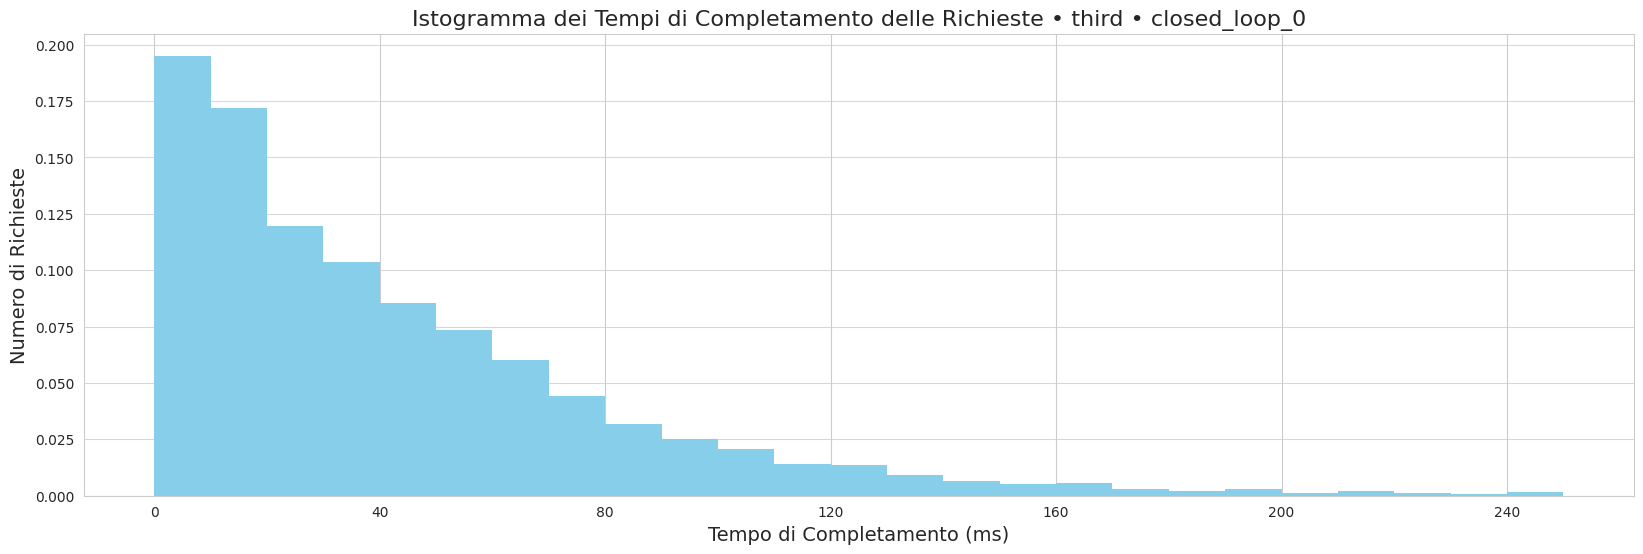

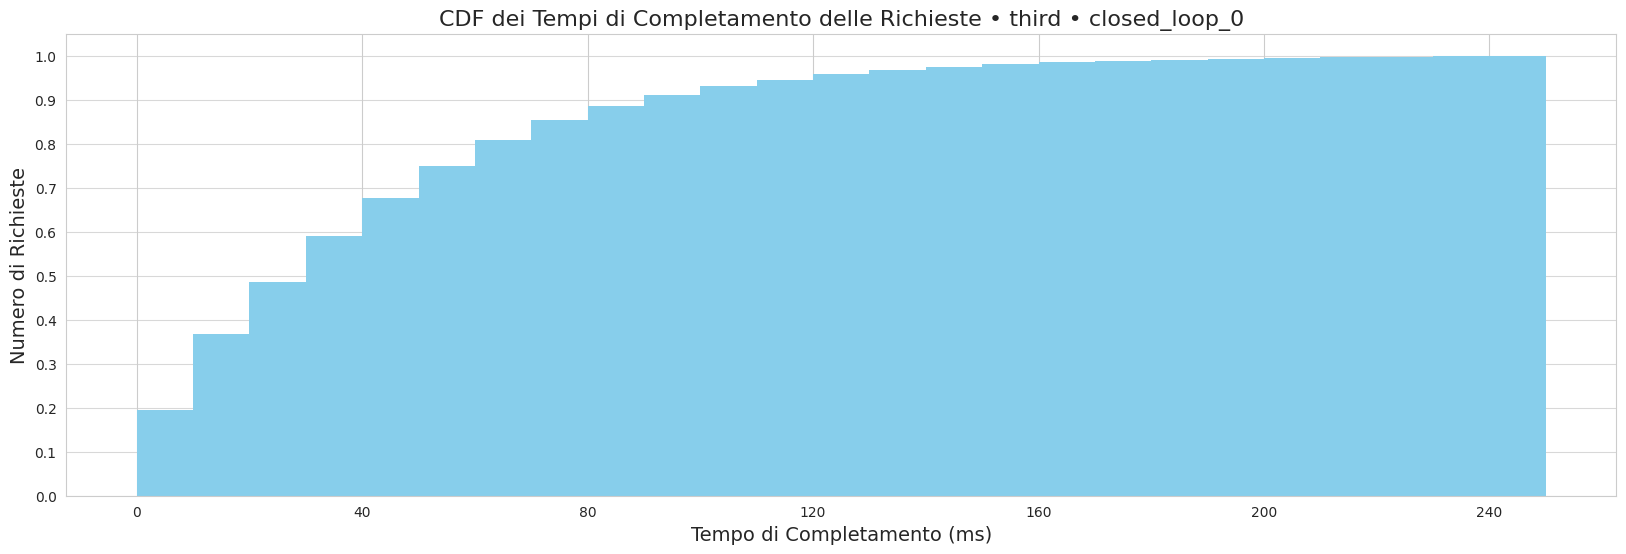

Media tempi di completamento per third • closed_loop_0: 43.32878896174176 ms
CDF: 0.20, 0.37, 0.49, 0.59, 0.68, 0.75, 0.81, 0.85, 0.89, 0.91, 0.93, 0.95, 0.96, 0.97, 0.97, 0.98, 0.99, 0.99, 0.99, 0.99, 0.99, 1.00, 1.00, 1.00, 1.00


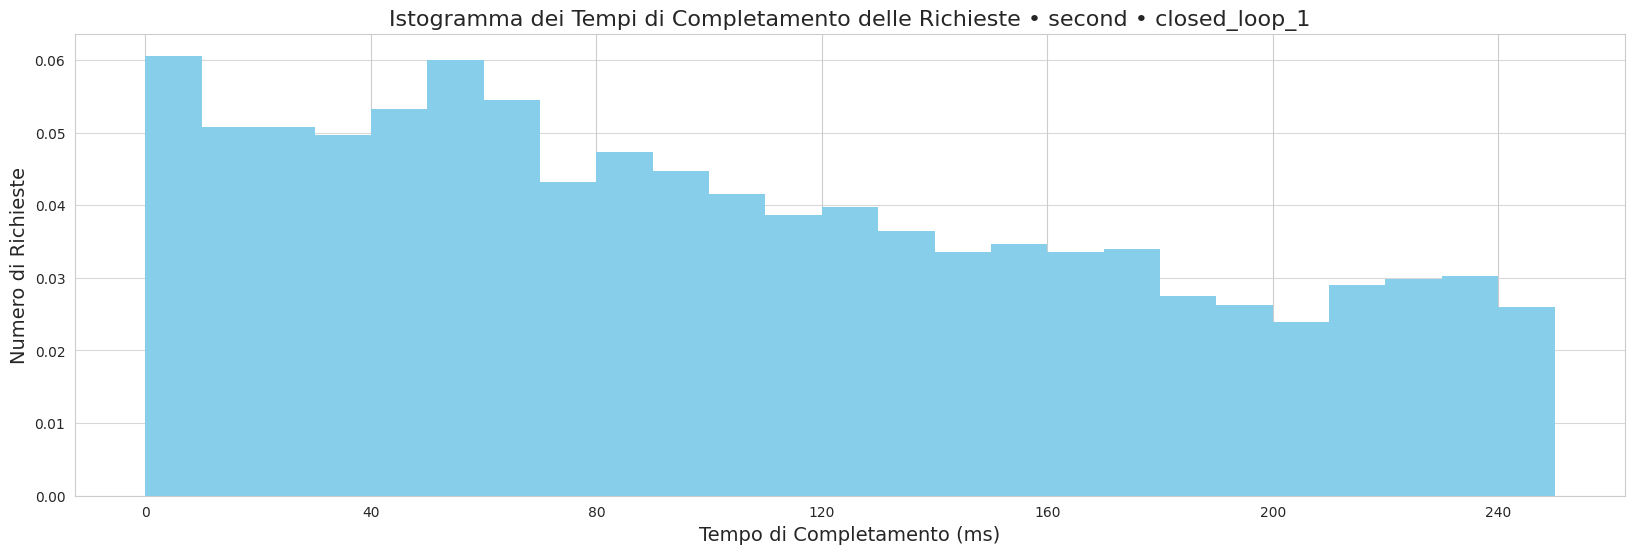

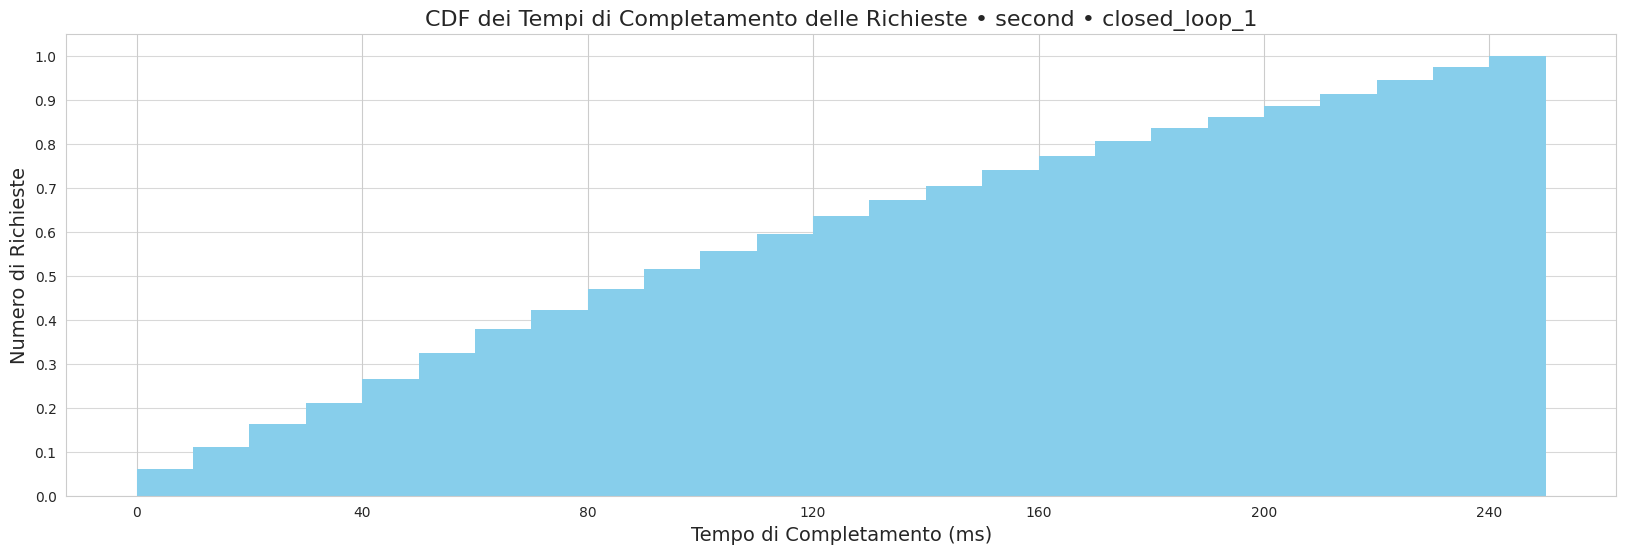

Media tempi di completamento per second • closed_loop_1: 293.7575257337354 ms
CDF: 0.06, 0.11, 0.16, 0.21, 0.26, 0.32, 0.38, 0.42, 0.47, 0.51, 0.56, 0.60, 0.63, 0.67, 0.70, 0.74, 0.77, 0.81, 0.83, 0.86, 0.88, 0.91, 0.94, 0.97, 1.00


In [40]:
histogram_completion_times_full(test_result, True, time_tick_ms, time_limit_ms)

In [41]:
# ora carichiamo i dati dalla cartella base di tutte le combinazioni di servizi utilizzate per predirre i nostri tempi
from options_utility import extract_unique_pairs
import random

def load_single_performance_results(num_cores: list, mu: list, service: str, concurrent_users: int, iteration: int, path: str = None) -> pd.DataFrame | None:
    folder_path = path
    
    file_path = os.path.join(folder_path, "metrics.json")
    with open(file_path) as train_file:
        dict = json.load(train_file)

    df = pd.json_normalize(dict['metrics'])
    df['users'] = df['vus_max.values.max']
    df['iteration'] = iteration
    df['duration'] = df['http_req_duration.values.avg']
    df['service'] = service
    df['mu'] = mu[0]
    df['cores'] = num_cores[0]

    return df

def load_performance_results(combinations) -> pd.DataFrame:
    # Load the results.
    df = pd.DataFrame()
    RESULT_FOLDER = 'base'
    
    for exp in combinations:
        service_type = exp['type']
        arg = exp['arg_values']
        path_incomplete = os.path.join(RESULT_FOLDER, service_type, "performance", f"{get_s([1])}_core", str(get_s(arg)), f"{str(1)}_users")
        if os.path.exists(path_incomplete):
            for iteration in os.listdir(path_incomplete):
                path = os.path.join(path_incomplete, str(iteration))
                df = pd.concat([df, load_single_performance_results([1], [arg], service_type, [1], iteration, path=path)], ignore_index=True)
        else:
            if service_type in ["deterministic"]:
                print("Check if the service name is correct.")
                for i in range(101):
                    data = {
                        'users': 1,
                        'iteration': 1,
                        'duration': arg[0] + random.uniform(-arg[0] * 0.01, arg[0] * 0.1),
                        'service': service_type,
                        'mu': arg[0],
                        'cores': 1
                    }

                    df = pd.concat([df, pd.DataFrame([data])], ignore_index=True)

    # remove the columns whose names contain the string 'contains' and 'type'
    df = df.loc[:,~df.columns.str.contains('contains|type')]
    # calc std
    df['duration_std'] = df.groupby(['service', 'mu', 'cores', 'users'])['duration'].transform('std')
    df = df.groupby(['service', 'mu', 'cores', 'users', 'duration_std']).agg({'duration': 'mean'}).reset_index()
    df['job_size'] = df['duration']

    return df.fillna(0)

performance_result = load_performance_results(extract_unique_pairs(options["WORKFLOW"]))
performance_result

,service,mu,cores,users,duration_std,duration,job_size
0,exponentialop,25000000,1,1,2.569413,46.022869,46.022869
1,exponentialop,50000000,1,1,5.627318,84.691966,84.691966


In [42]:
def calc_mean_users_per_workflow(all_data: pd.DataFrame) -> pd.DataFrame:
    """
    Calcola il numero medio di utenti per ogni workflow.
    """
    if all_data.empty:
        print("DataFrame vuoto: impossibile calcolare il numero medio di utenti.")
        return pd.DataFrame(columns=["scenario", "mean_users"])

    df = all_data[["scenario", "service_name", "service", "mu", "cores", "start_time_us", "end_time_us", 'iteration']].copy()

    users = (df.groupby(["scenario", "service_name", "service", "mu", 'iteration', "cores"], dropna=False)
        .apply(lambda x: calculate_concurrency(x, x['start_time_us'].min(), x['end_time_us'].max()))
        .reset_index(level=[0,1,2])
        .groupby(["scenario", "service_name", 'timestamp', "service", "mu", "cores"], dropna=False)["concurrent_users"]
        .mean()
        .reset_index()
    )

    users["concurrent_users"] = users["concurrent_users"].apply(lambda x: math.ceil(x)).astype(int)
    
    result = (
        users
        .groupby(["scenario", "service_name", "service", "mu", "cores"], dropna=False)["concurrent_users"]
        .mean()
        .reset_index()
        .rename(columns={"concurrent_users": "mean_users"})
        .sort_values(["scenario", "service_name", "service", "mu", "cores"])
        .reset_index(drop=True)
    )

    return result

mean_users_per_workflow = calc_mean_users_per_workflow(test_result)
mean_users_per_workflow

/tmp/ipykernel_1736/241611524.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: calculate_concurrency(x, x['start_time_us'].min(), x['end_time_us'].max()))


,scenario,service_name,service,mu,cores,mean_users
0,closed_loop_0,first,exponentialop,50000000,3,1.733333
1,closed_loop_0,second,exponentialop,25000000,2,3.933333
2,closed_loop_0,third,exponentialop,25000000,3,1.000000
3,closed_loop_1,second,exponentialop,25000000,2,9.000000


In [43]:
from subprocess import Popen
from time import sleep

def get_theoretical_cdf(model_type, mean_users_per_workflow, performance_result, time_tick_ms: int, time_limit_ms: int) -> list[float]:
    process = Popen(['java', '-cp', '../../rospo-1.0-SNAPSHOT.jar', 'parallel.Py4jEntryPoint'])
    print(process.pid)
    sleep(1)  # wait for the JVM to start

    try:
        from py4j.java_gateway import JavaGateway
        gateway = JavaGateway()
        from py4j.java_gateway import java_import
        java_import(gateway.jvm,'java.math.*')

        print( "Setting model..." )
        print( f"Model type: {model_type}" )

        mean_users_per_workflow_cp = mean_users_per_workflow.copy()
        mean_users_per_workflow_cp = mean_users_per_workflow_cp.groupby(['service_name', 'service', 'mu', 'cores']).sum().reset_index()

        loadMap = gateway.jvm.java.util.HashMap()
        coreMap = gateway.jvm.java.util.HashMap()  
        keys = gateway.new_array(gateway.jvm.java.lang.String, len(mean_users_per_workflow_cp))

        for i, row in enumerate(mean_users_per_workflow_cp.itertuples()):
            key = f"{row.service_name}"
            duration = (performance_result[(performance_result['service'] == row.service) & (performance_result['mu'] == row.mu)]['duration'].values[0])
            keys[i] = key

            match row.service:
                case "deterministic":
                    print("Adding deterministic distribution for", key, "with duration", duration)
                    gateway.entry_point.addDeterministicDistribution(float(duration))
                case "exponential" | "exponentialop":
                    print("Adding exponential distribution for", key, "with duration", duration)
                    gateway.entry_point.addExponentialDistribution(key, float(1 / duration))
                    time_limit_ms = int(duration) * 10 if time_limit_ms < 0 else time_limit_ms
                case "erlang":
                    print("Adding erlang distribution for", key, "with duration", duration)
                    gateway.entry_point.addErlangDistribution(key, int(duration[0]), float(duration[1]))
                case "uniform":
                    print("Adding uniform distribution for", key, "with duration", duration)
                    gateway.entry_point.addUniformDistribution(key, float(duration[0]), float(duration[1]))
                case "trunc_exp":
                    print("Adding truncated exponential distribution for", key, "with duration", duration)
                    gateway.entry_point.addTruncatedExponentialDistribution(key, float(duration[0]), float(duration[1]), float(duration[2]))
                case _:
                    gateway.entry_point.addExponentialDistribution(key, float(1 / duration))

            print("Adding load and cores for", key, "with mean users", row.mean_users, "and cores", row.cores)
            loadMap.put(key, float(row.mean_users))
            coreMap.put(key, int(row.cores))

        gateway.entry_point.setModel(model_type, keys)
        theoretical_cdf = list(gateway.entry_point.evalModel(coreMap, loadMap, float(time_tick_ms), float(time_limit_ms)))

        gateway.close()
        gateway.shutdown()
    except Exception as e:
        print("Errore durante l'esecuzione del modello teorico:", e)
        theoretical_cdf = []

    return theoretical_cdf

theoretical_cdf = get_theoretical_cdf(options["TEST_SERVICE"].split('_')[1], mean_users_per_workflow, performance_result, time_tick_ms, 1500)
theoretical_cdf

11656
Gateway Server Started
Setting model...
Model type: seq
Adding exponential distribution for first with duration 84.69196577778376
Adding load and cores for first with mean users 1.7333333333333334 and cores 3
Adding exponential distribution for second with duration 46.02286920131694
Adding load and cores for second with mean users 12.933333333333334 and cores 2
Adding exponential distribution for third with duration 46.02286920131694
Adding load and cores for third with mean users 1.0 and cores 3
Evaluating model: SEQ(first, second, third)
Evaulating for 1500.0 with tick 10.0
CDF Values: 151
CDF: [0.0, 1.7967110730685655E-4, 0.0010169904181868998, 0.003001503587903068, 0.00643535505923677, 0.011480869229101687, 0.01819759094992766, 0.026570983773473607, 0.03653453939900594, 0.04798669547747832, 0.060803673744510615, 0.07484912234368535, 0.08998126385987176, 0.10605810493538813, 0.12294114710263697, 0.14049794578482924, 0.15860379059554644, 0.1771427213398971, 0.19600804746201728,

[0.0,
 0.00017967110730685655,
 0.0010169904181868998,
 0.003001503587903068,
 0.00643535505923677,
 0.011480869229101687,
 0.01819759094992766,
 0.026570983773473607,
 0.03653453939900594,
 0.04798669547747832,
 0.060803673744510615,
 0.07484912234368535,
 0.08998126385987176,
 0.10605810493538813,
 0.12294114710263697,
 0.14049794578482924,
 0.15860379059554644,
 0.1771427213398971,
 0.19600804746201728,
 0.2151025016714887,
 0.2343381291716494,
 0.25363599074861315,
 0.2729257397139696,
 0.2921451183282486,
 0.311239408067587,
 0.33016085929402,
 0.34886811904021825,
 0.3673256703149931,
 0.3855032922516211,
 0.4033755472981591,
 0.4209212992814188,
 0.4381232644003936,
 0.45496759589075025,
 0.4714435021465173,
 0.4875428974068958,
 0.5032600836509319,
 0.5185914620400273,
 0.5335352720682206,
 0.5480913564917927,
 0.5622609500888308,
 0.5760464903271314,
 0.5894514480807839,
 0.6024801766208233,
 0.6151377772050393,
 0.6274299797000393,
 0.6393630367802462,
 0.650943630360214,
 0.

11696
Gateway Server Started
Setting model...
Model type: seq
Adding exponential distribution for first with duration 84.69196577778376
Adding load and cores for first with mean users 1.7333333333333334 and cores 3
Adding exponential distribution for second with duration 46.02286920131694
Adding load and cores for second with mean users 12.933333333333334 and cores 2
Adding exponential distribution for third with duration 46.02286920131694
Adding load and cores for third with mean users 1.0 and cores 3
Evaluating model: SEQ(first, second, third)
Evaulating for 1500.0 with tick 10.0
CDF Values: 151
CDF: [0.0, 1.7967110730685655E-4, 0.0010169904181868998, 0.003001503587903068, 0.00643535505923677, 0.011480869229101687, 0.01819759094992766, 0.026570983773473607, 0.03653453939900594, 0.04798669547747832, 0.060803673744510615, 0.07484912234368535, 0.08998126385987176, 0.10605810493538813, 0.12294114710263697, 0.14049794578482924, 0.15860379059554644, 0.1771427213398971, 0.19600804746201728,

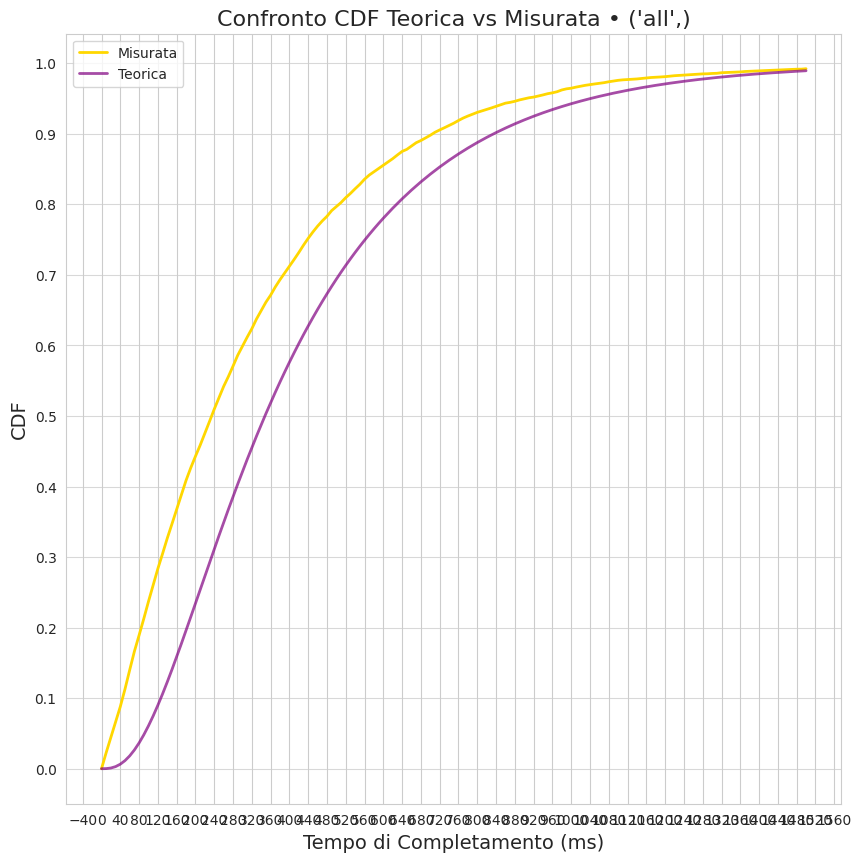

In [44]:
def compare_cdfs(iteration_results, model_type, mean_users_per_workflow, performance_result, time_tick_ms: int = 100, time_limit_ms: int = 250):
    """
    Confronta le CDF teoriche con quelle misurate e crea un grafico.

    Args:
        iteration_results (pd.DataFrame): DataFrame contenente i risultati delle iterazioni.
        theoretical_cdf (list): Lista delle CDF teoriche calcolate.
        time_tick_ms (int): Intervallo di tempo in millisecondi per il calcolo della CDF.
        time_limit_ms (int): Limite massimo di tempo in millisecondi per il grafico.
    """
    for service, group in iteration_results.groupby(['service_name']):
        if service == 'all':
            continue

        times = group['metric_value']
        if times.empty:
            continue
        count, bins = np.histogram(times, bins=range(0, int(times.max()), time_tick_ms))
        cdf_measured = np.cumsum(count) / count.sum()

        if time_limit_ms is not None:
            limit_index = min(len(cdf_measured), time_limit_ms // time_tick_ms)
            cdf_measured = cdf_measured[:limit_index]
            bins = bins[:limit_index + 1]

        cdf_measured = np.pad(cdf_measured, (1, 0))

         # plot the measured cdf

        plt.figure(figsize=(10, 10))
        plt.plot(bins, cdf_measured, color='gold', label='Misurata', linewidth=2)
        
        # plot the theoretical cdf
        #theoretical_cdf.pop(0)
        theoretical_cdf = get_theoretical_cdf(model_type, mean_users_per_workflow, performance_result, time_tick_ms, time_limit_ms)
        #theoretical_cdf = theoretical_cdf[1:]
        plt.plot(bins, theoretical_cdf, color='purple', label='Teorica', alpha=0.7, linewidth=2)

        plt.title(f"Confronto CDF Teorica vs Misurata • {service}", fontsize=16)
        plt.xlabel("Tempo di Completamento (ms)", fontsize=14)
        plt.ylabel("CDF", fontsize=14)
        plt.yticks(np.arange(0, 1.1, 0.1))
        plt.gca().xaxis.set_major_locator(MultipleLocator(time_tick_ms * 4))
        plt.grid(axis='y', alpha=0.75)
        plt.legend()
        plt.show()
        plt.close()

compare_cdfs(iteration_results, options["TEST_SERVICE"].split('_')[1], mean_users_per_workflow, performance_result, time_tick_ms, 1500)

11737
Gateway Server Started
Setting model...
Model type: simple
Adding exponential distribution for second with duration 46.02286920131694
Adding load and cores for second with mean users 12.933333333333334 and cores 2
Evaluating model: second
Evaulating for 250.0 with tick 10.0
CDF Values: 26
CDF: [0.0, 0.033042279962624765, 0.06499276766012108, 0.09588753839817432, 0.1257614754721197, 0.15464830955368192, 0.18258065677628732, 0.2095900555619501, 0.2357070022313149, 0.2609609854370615, 0.28538051945955245, 0.3089931764023155, 0.3318256173237142, 0.3539036223399581, 0.37525211973343897, 0.395895214099263, 0.4158562135617567, 0.4351576560916768, 0.4538213349538408, 0.4718683233139087, 0.489318998032101, 0.5061930626707181, 0.5225095697414385, 0.538286942217516, 0.5535429943351644, 0.568294951707617]


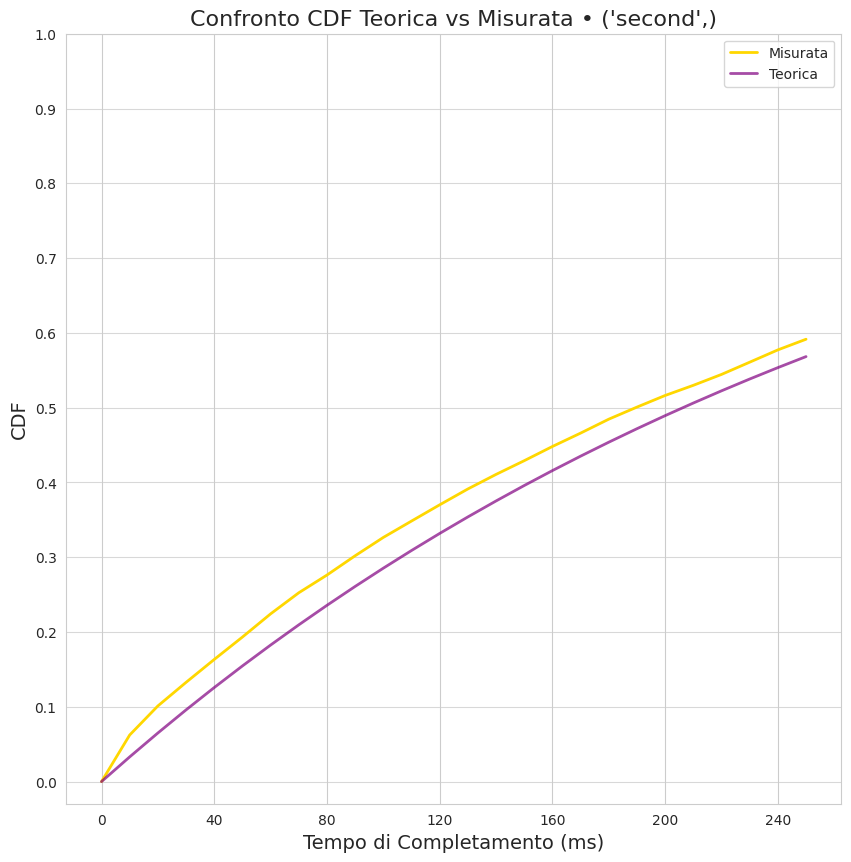

11771
Gateway Server Started
Setting model...
Model type: simple
Adding exponential distribution for first with duration 84.69196577778376
Adding load and cores for first with mean users 1.7333333333333334 and cores 3
Evaluating model: first
Evaulating for 250.0 with tick 10.0
CDF Values: 26
CDF: [0.0, 0.11137055659720041, 0.21033771231763054, 0.2982828408206347, 0.3764334714122468, 0.445880422776449, 0.5075930285132413, 0.5624326670000634, 0.6111647844250189, 0.6544695788081969, 0.692951494137593, 0.7271476571378281, 0.7575353744312383, 0.7845387947359631, 0.8085348290913226, 0.8298584117444001, 0.8488071751287579, 0.8656456041881712, 0.8806087280310151, 0.8939054004430487, 0.9057212150476635, 0.916221095803113, 0.9255515989946238, 0.9338429588523641, 0.9412109053478003, 0.9477582795410612]


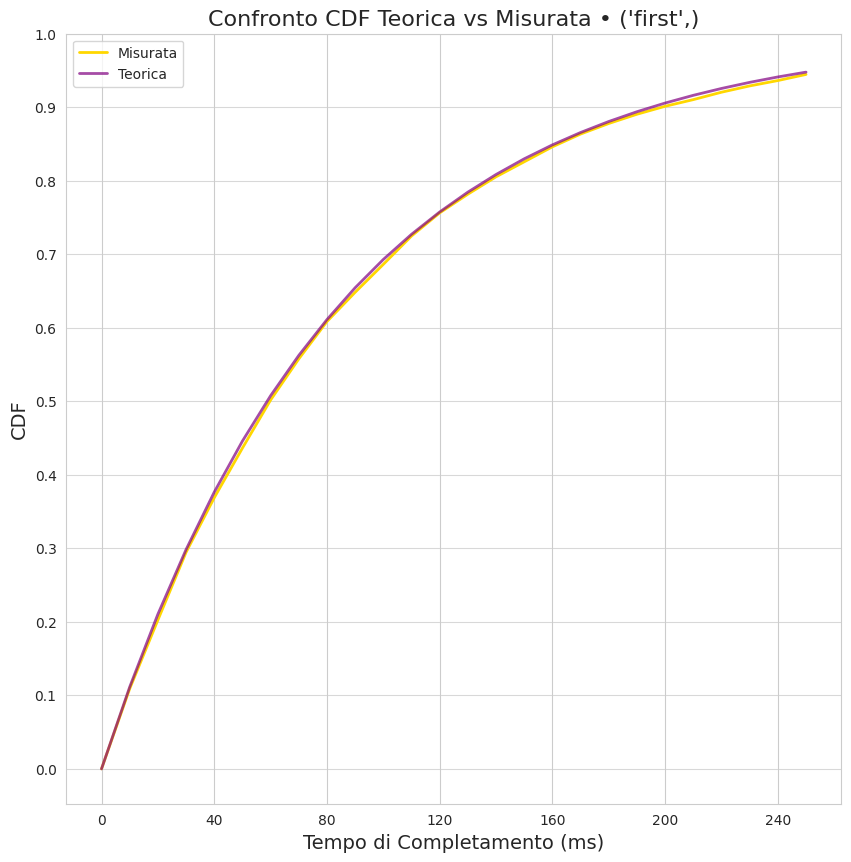

11799
Gateway Server Started
Setting model...
Model type: simple
Adding exponential distribution for third with duration 46.02286920131694
Adding load and cores for third with mean users 1.0 and cores 3
Evaluating model: third
Evaulating for 250.0 with tick 10.0
CDF Values: 26
CDF: [0.0, 0.19529801939876246, 0.3524547224164456, 0.4789190325995357, 0.5806851134792375, 0.6625764803211593, 0.7284746254129962, 0.7815029932863451, 0.82417502594208, 0.8585132951364306, 0.886145368367543, 0.9083809524247375, 0.9262739709553873, 0.9406725184059358, 0.952259058057173, 0.9615827694628385, 0.9690855784975317, 0.9751231037878223, 0.9799815123468492, 0.9838910833368681, 0.9870371228558376, 0.989568747087802, 0.9916059501214018, 0.9932452914374265, 0.9945644726413129, 0.9956260203688523]


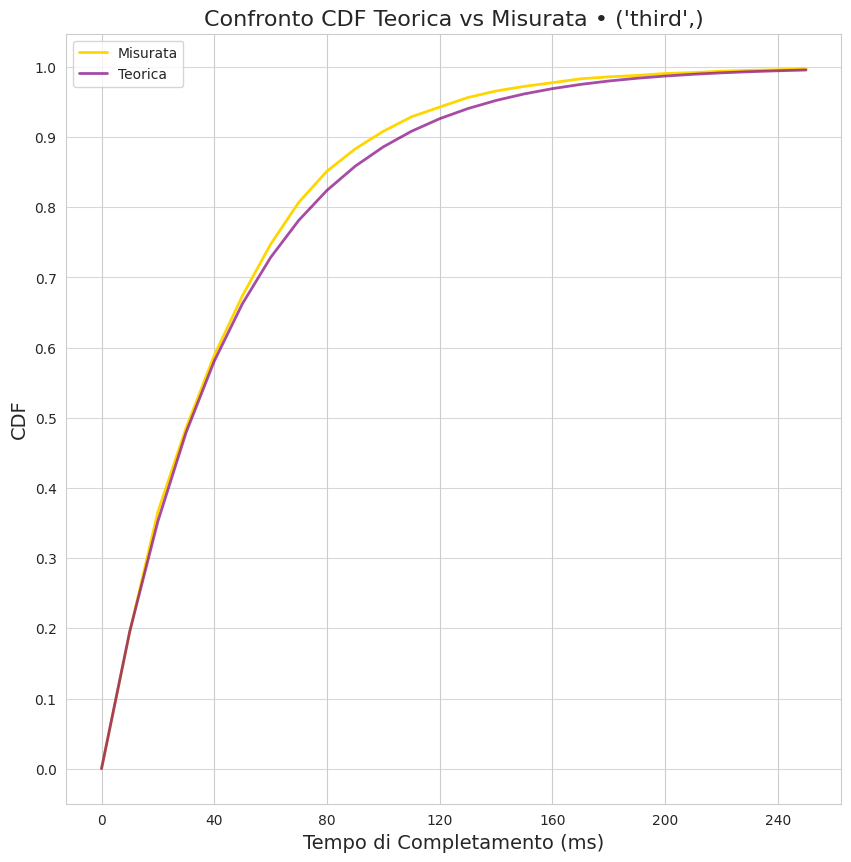

In [45]:
def compare_all_cdfs(test_result, mean_users_per_workflow, performance_result, time_tick_ms: int = 100, time_limit_ms: int = 250):
    service_names = test_result['service_name'].unique()
    for service_name in service_names:
        compare_cdfs(test_result[test_result["service_name"] == service_name], "simple", mean_users_per_workflow[mean_users_per_workflow["service_name"] == service_name], performance_result, time_tick_ms, time_limit_ms)

compare_all_cdfs(test_result, mean_users_per_workflow, performance_result, time_tick_ms, time_limit_ms)

Scenario: open_loop_0, Service: exponentialop, Service Name: first, Lambda: 6.0, Mu: 50000000, Cores: 2, Job Size: 84.69 ms, Mean Users: 1.03, Ro: 0.51, SCV: 1.00, MMK: 1.04
Scenario: open_loop_0, Service: exponentialop, Service Name: fourth, Lambda: 14.0, Mu: 25000000, Cores: 2, Job Size: 46.02 ms, Mean Users: 1.98, Ro: 0.64, SCV: 1.00, MMK: 1.96
Scenario: open_loop_0, Service: exponentialop, Service Name: second, Lambda: 6.0, Mu: 50000000, Cores: 2, Job Size: 84.69 ms, Mean Users: 1.11, Ro: 0.51, SCV: 1.00, MMK: 1.04
Scenario: open_loop_0, Service: exponentialop, Service Name: third, Lambda: 14.0, Mu: 25000000, Cores: 2, Job Size: 46.02 ms, Mean Users: 1.84, Ro: 0.64, SCV: 1.00, MMK: 1.96


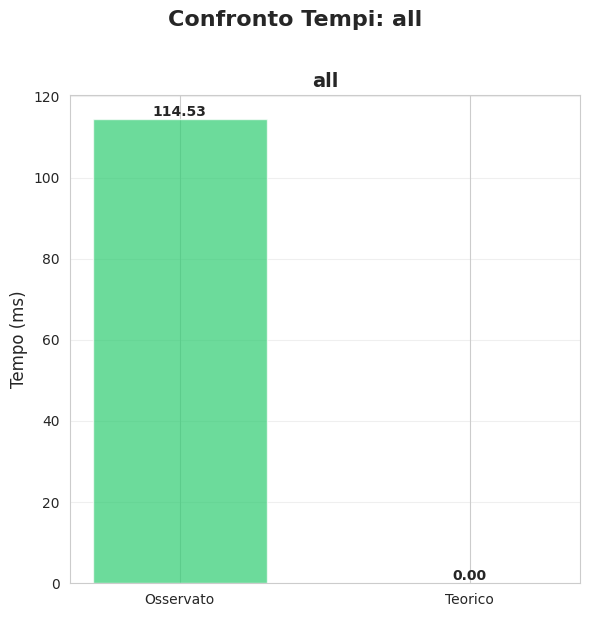

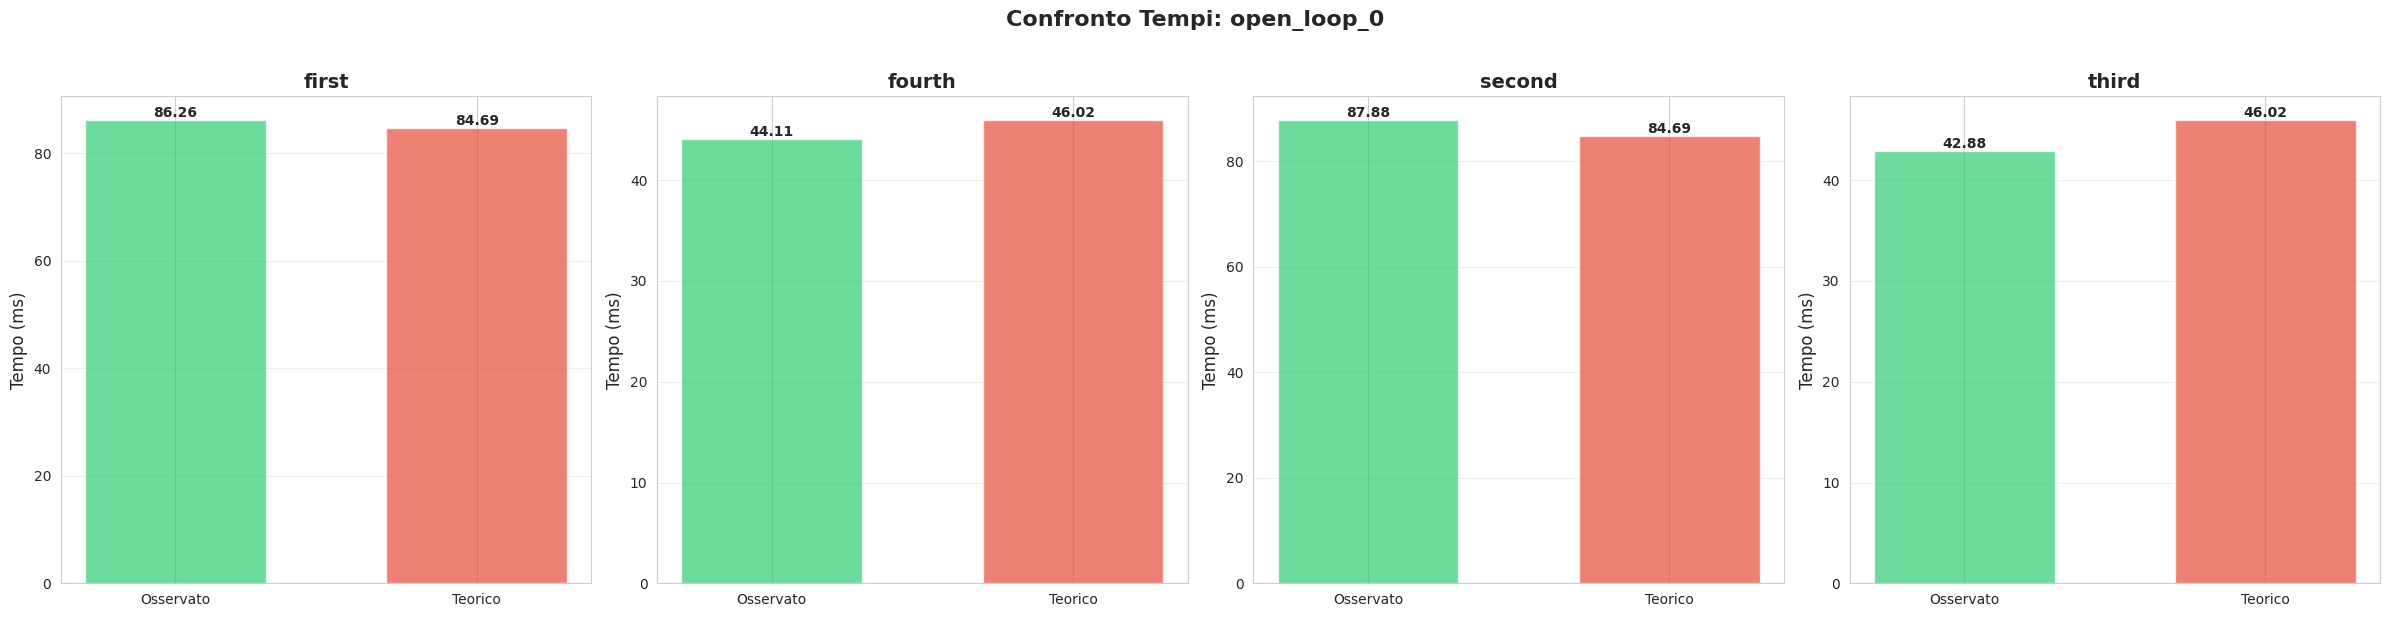

In [15]:
from scipy import stats

def get_scv(service: str, params: list[float]) -> float:
    """
    Returns the squared coefficient of variation for the service times
    of a stochastic process, the ratio between the variance and the mean squared.
    """
    match service:
        case "deterministic" | "deterministic_core":
            return 0.0
        case "exponential" | "exponentialop":
            return 1.0
        case "uniform":
            a = params[0]
            b = params[1]
            variance = (b - a) ** 2 / 12
            mean = (a + b) / 2
            return variance / (mean ** 2)
        case _:
            variance = params[0]
            mean = params[1]
            return variance / (mean ** 2)

def create_user_load_prediction_plot(requests_df: pd.DataFrame, performance_data: pd.DataFrame, recalc: bool = True, time_step_ms: int = 500):
    requests_df = requests_df.copy()

    bin_width_us = time_step_ms * 1000

    requests_df['segment'] = requests_df['service'] + ' • ' + requests_df['scenario'] + ' • ' + requests_df['service_name']
    requests_df['start_bin_idx'] = (requests_df['start_time_us'] // bin_width_us).astype(int)
    requests_df['end_bin_idx'] = (
        (np.maximum(requests_df['end_time_us'] - 1, requests_df['start_time_us'])) // bin_width_us
    ).astype(int)

    # Calcola il numero di utenti concorrenti per ogni bin
    start_events = (
        requests_df.groupby(['iteration', 'segment', 'start_bin_idx'])
        .size()
        .rename('delta')
        .reset_index()
        .rename(columns={'start_bin_idx': 'bin_idx'})
    )
    end_events = (
        requests_df.groupby(['iteration', 'segment', 'end_bin_idx'])
        .size()
        .rename('delta')
        .reset_index()
        .rename(columns={'end_bin_idx': 'bin_idx'})
    )
    end_events['bin_idx'] += 1
    end_events['delta'] = -end_events['delta']

    events = pd.concat([start_events, end_events], ignore_index=True)
    events['bin_idx'] = events['bin_idx'].astype(int)
    changes = events.pivot_table(index=['iteration', 'bin_idx'], columns='segment', values='delta', aggfunc='sum', fill_value=0)

    min_bin = int(requests_df['start_bin_idx'].min())
    max_bin = int(requests_df['end_bin_idx'].max()) + 1
    iterations = sorted(requests_df['iteration'].unique())
    full_index = pd.MultiIndex.from_product([iterations, range(min_bin, max_bin + 1)], names=['iteration', 'bin_idx'])
    changes = changes.reindex(full_index, fill_value=0)

    user_counts = changes.groupby(level='iteration').cumsum()
    mean_user_counts = user_counts.groupby(level='bin_idx').mean()
    
    if mean_user_counts.empty:
        print("Impossibile calcolare la media delle richieste attive.")
        return
    
    mean_user_counts.index = mean_user_counts.index.astype(int) * time_step_ms

    column_tuples = []
    for seg in mean_user_counts.columns:
        parts = seg.split(' • ', 2)
        if len(parts) == 3:
            service, scenario, service_name = parts
        else:
            service, scenario, service_name = seg, 'sconosciuto', 'sconosciuto'
        column_tuples.append((scenario.strip(), service.strip(), service_name.strip()))
    mean_user_counts.columns = pd.MultiIndex.from_tuples(column_tuples, names=['scenario', 'service', 'service_name'])

    # Calcola i tempi osservati medi per scenario e servizio
    observed_times = (
        requests_df.groupby(['scenario', 'service', 'service_name', 'mu', 'lambda'])['metric_value']
        .mean()
        .reset_index()
        .rename(columns={'metric_value': 'observed_time_ms'})
    )

    # Calcola i tempi teorici usando la formula di check_law
    theoretical_times = []
    for _, row in observed_times.iterrows():
        scenario = row['scenario']
        service = row['service']
        service_name = row['service_name']
        mu = row['mu']
        
        # Ottieni il job_size dal performance_data
        perf_match = performance_data[
            (performance_data['service'] == service) &
            (performance_data['mu'] == mu) & 
            (performance_data['users'] == 1) &
            (performance_data['cores'] == 1)
        ]
        
        if not perf_match.empty:
            
            # Ottieni cores e mu dal test_result
            test_match = requests_df[
                (requests_df['scenario'] == scenario) & 
                (requests_df['service'] == service) & 
                (requests_df['service_name'] == service_name)
            ]
            
            if not test_match.empty:
                cores = int(test_match['cores'].iloc[0] * 1)#6
                l = test_match['lambda'].iloc[0]
                mean_users = mean_user_counts.loc[:, (slice(None), slice(None), service_name)][(np.abs(stats.zscore(mean_user_counts)) < 2).all(axis=1)].mean().sum()
                #mean_users = mean_users if mean_users > 1 else 1
                job_size = test_match['metric_value'].mean() * np.minimum(cores, mean_users) / mean_users if recalc else perf_match['job_size'].values[0]
                
                # Calcola il numero medio di utenti concorrenti per questo scenario/servizio
                # Somma tra di loro gli utenti che incidono sullo stesso service_name anche se su due scenari diversi
                service_rate = 1000 / (job_size)  
                ro = l / (service_rate)
                std = perf_match['duration_std'].values[0] if 'duration_std' in perf_match else 0
                mmk = ro + (ro / (1 - ro)) * erlangC(cores, ro * cores) * (get_scv(service, [mu, std]) + get_scv("deterministic", 1000 / (ro * mu * cores))) / 2
                print(f"Scenario: {scenario}, Service: {service}, Service Name: {service_name}, Lambda: {l}, Mu: {mu}, Cores: {cores}, Job Size: {job_size:.2f} ms, Mean Users: {mean_users:.2f}, Ro: {ro:.2f}, SCV: {get_scv(service, [mu, std]):.2f}, MMK: {mmk:.2f}")
                mean_mmk = 1 if mmk <= 1 else mmk
                theoretical_time = mean_mmk * job_size / np.minimum(cores, mean_mmk)

                # Calcola il tempo teorico: T = L * X / min(cores, L)               
                theoretical_times.append({
                    'scenario': scenario,
                    'service_name': service_name,
                    'service': service,
                    'mu': mu,
                    'lambda': l,
                    'theoretical_time_ms': theoretical_time,
                    'cores': cores,
                    'concurrent_users': mean_mmk
                })

    theoretical_df = pd.DataFrame(theoretical_times)
    
    # Merge observed and theoretical times
    comparison_df = observed_times.merge(theoretical_df, on=['scenario', 'service', 'service_name', 'lambda'], how='left')

    # Crea i grafici
    scenarios = sorted(requests_df['scenario'].unique())

    for scenario in scenarios:
        scenario_comparison = comparison_df[comparison_df['scenario'] == scenario]

        if scenario_comparison.empty:
            continue

        services = scenario_comparison['service_name'].unique()
        num_services = len(services)

        fig, axes = plt.subplots(1, num_services, figsize=(6 * num_services, 6))
        if num_services == 1:
            axes = [axes]

        for idx, service_name in enumerate(services):
            ax = axes[idx]
            service_data = scenario_comparison[scenario_comparison['service_name'] == service_name]

            if service_data.empty:
                continue

            x = np.arange(2)
            observed = service_data['observed_time_ms'].values[0]
            theoretical = service_data['theoretical_time_ms'].values[0] if not pd.isna(service_data['theoretical_time_ms'].values[0]) else 0

            bars = ax.bar(x, [observed, theoretical], color=['#2ecc71', '#e74c3c'], alpha=0.7, width=0.6)
            ax.set_xticks(x)
            ax.set_xticklabels(['Osservato', 'Teorico'])
            ax.set_ylabel('Tempo (ms)', fontsize=12)
            ax.set_title(f'{service_name}', fontsize=14, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)

            # Aggiungi valori sopra le barre
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}',
                       ha='center', va='bottom', fontsize=10, fontweight='bold')

        fig.suptitle(f'Confronto Tempi: {scenario}{" (Ricalcolato)" if recalc else ""}', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

# create_user_load_prediction_plot(test_result, performance_result, time_step_ms=200)
create_user_load_prediction_plot(test_result, performance_result, recalc=False, time_step_ms=100)

Confronto senza ricalcolo del peso:


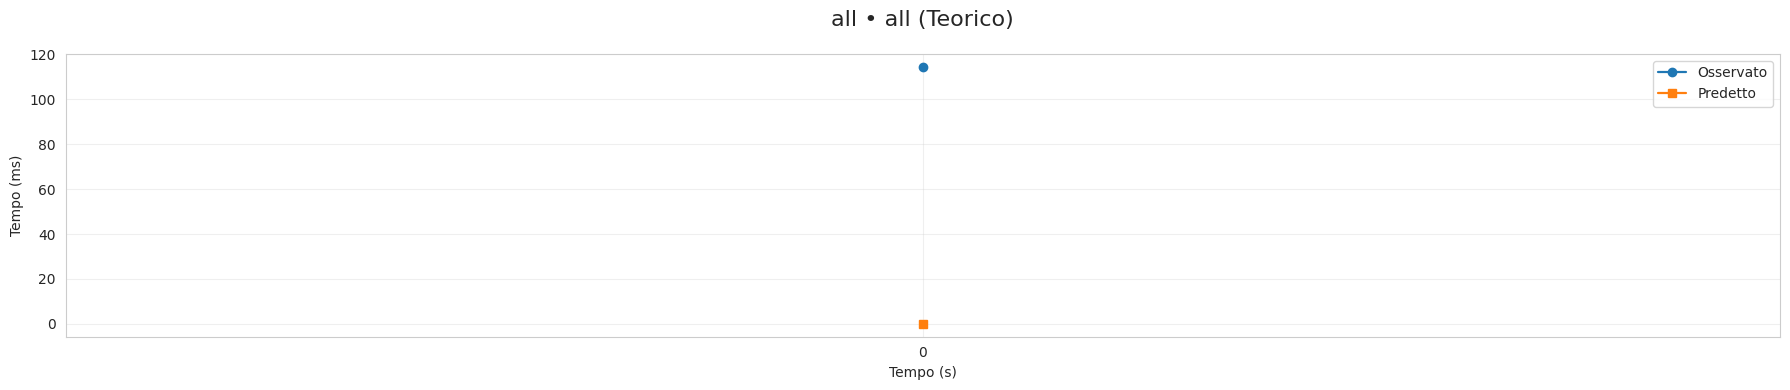

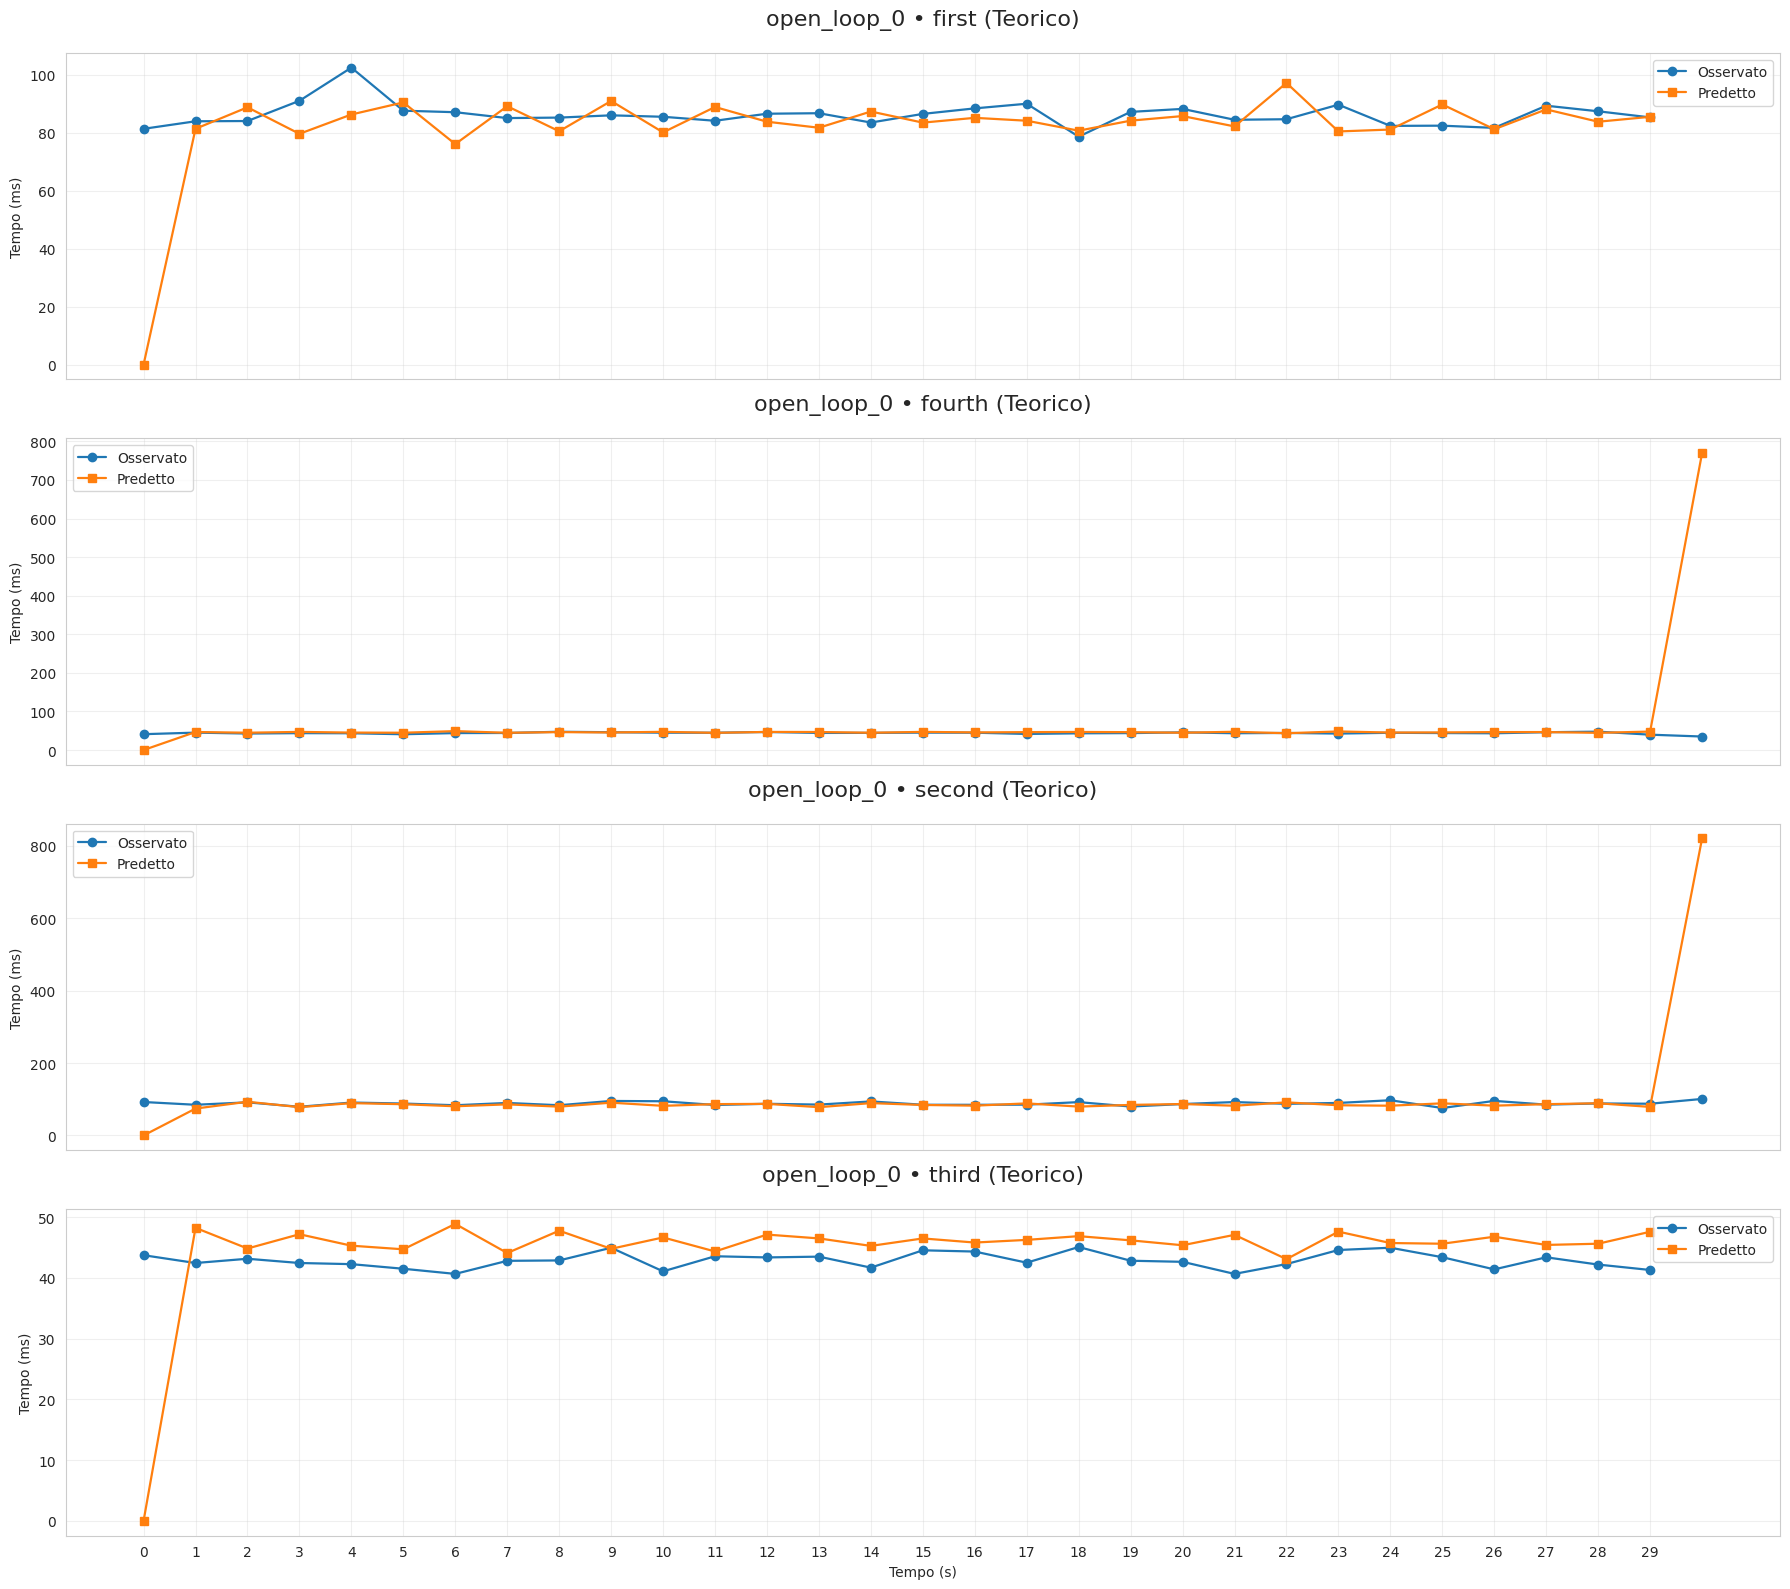

,time_ms,concurrent_users,scenario,service,service_name,time_s,lambda,mu,observed_time_ms,resources,users,duration_std,duration,weight_ms,assigned_resources,effective_resources,previous_users,predicted_time_ms
0,0,1.0000,all,all,all,0.0,0.0,0.0,114.529503,16.0,NaN,NaN,NaN,84.691966,0.0,1.0000,0.0000,0.000000
5,1000,0.0000,all,all,all,1.0,NaN,NaN,NaN,16.0,NaN,NaN,NaN,84.691966,0.0,1.0000,1.0000,84.691966
10,2000,0.0000,all,all,all,2.0,NaN,NaN,NaN,16.0,NaN,NaN,NaN,84.691966,0.0,1.0000,0.0000,0.000000
15,3000,0.0000,all,all,all,3.0,NaN,NaN,NaN,16.0,NaN,NaN,NaN,84.691966,0.0,1.0000,0.0000,0.000000
20,4000,0.0000,all,all,all,4.0,NaN,NaN,NaN,16.0,NaN,NaN,NaN,84.691966,0.0,1.0000,0.0000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,27000,14.5875,open_loop_0,exponentialop,third,27.0,14.0,25000000.0,43.393250,32.0,1.0,2.569413,46.022869,46.022869,2.0,14.5875,14.4000,45.431316
144,28000,14.7125,open_loop_0,exponentialop,third,28.0,14.0,25000000.0,42.198143,32.0,1.0,2.569413,46.022869,46.022869,2.0,14.7125,14.5875,45.631851
149,29000,14.2250,open_loop_0,exponentialop,third,29.0,14.0,25000000.0,41.306704,32.0,1.0,2.569413,46.022869,46.022869,2.0,14.2250,14.7125,47.600103
154,30000,0.3500,open_loop_0,exponentialop,third,30.0,NaN,NaN,NaN,32.0,NaN,NaN,NaN,46.022869,2.0,0.3500,14.2250,1870.500898


In [16]:
def create_user_load_prediction_comparison(requests_df: pd.DataFrame,
                                           theoretical_data: pd.DataFrame,
                                           recalc: bool = True,
                                           time_step_ms: int = 1000) -> pd.DataFrame:
    """
    Confronta l'andamento osservato con una predizione basata sulla formula T = L·X / R,
    usando finestre di 1 secondo.
    """
    if requests_df.empty:
        print("DataFrame vuoto: impossibile generare il confronto.")
        return pd.DataFrame()

    if 'service_name' not in requests_df.columns:
        requests_df = requests_df.copy()
        requests_df['service_name'] = requests_df['extra_tags'].apply(parse_service_name)

    required_cols = {'scenario', 'service_name', 'metric_value', 'start_time_us', 'end_time_us'}
    if not required_cols.issubset(requests_df.columns):
        missing = required_cols - set(requests_df.columns)
        raise ValueError(f"Mancano colonne necessarie nel DataFrame richiesto: {missing}")

    weight_df = theoretical_data.copy()

    if 'weight_ms' not in weight_df.columns:
        for cand in ('job_size', 'duration', 'mean_service_time_ms'):
            if cand in weight_df.columns:
                weight_df = weight_df.rename(columns={cand: 'weight_ms'})
                break
        else:
            raise ValueError("Il DataFrame teorico deve fornire un peso in ms (es. 'job_size').")

    if 'resources' not in weight_df.columns:
        if 'cores' in weight_df.columns:
            weight_df = weight_df.rename(columns={'cores': 'resources'})
        else:
            weight_df['resources'] = 1

    bin_width_us = time_step_ms * 1000
    df = requests_df.copy()
    df['segment'] = df['scenario'] + ' • ' + df["service"] + ' • ' + df['service_name']
    df['start_bin_idx'] = (df['start_time_us'] // bin_width_us).astype(int)
    df['end_bin_idx'] = ((np.maximum(df['end_time_us'] - 1, df['start_time_us'])) // bin_width_us).astype(int)

    start_events = (
        df.groupby(['iteration', 'segment', 'start_bin_idx'])
          .size().rename('delta').reset_index()
          .rename(columns={'start_bin_idx': 'bin_idx'})
    )
    end_events = (
        df.groupby(['iteration', 'segment', 'end_bin_idx'])
          .size().rename('delta').reset_index()
          .rename(columns={'end_bin_idx': 'bin_idx'})
    )
    end_events['bin_idx'] += 1
    end_events['delta'] = -end_events['delta']

    events = pd.concat([start_events, end_events], ignore_index=True)
    events['bin_idx'] = events['bin_idx'].astype(int)
    changes = events.pivot_table(index=['iteration', 'bin_idx'],
                                 columns='segment',
                                 values='delta',
                                 aggfunc='sum',
                                 fill_value=0)

    min_bin = int(df['start_bin_idx'].min())
    max_bin = int(df['end_bin_idx'].max()) + 1
    iterations = sorted(df['iteration'].unique())
    full_index = pd.MultiIndex.from_product([iterations, range(min_bin, max_bin + 1)],
                                            names=['iteration', 'bin_idx'])
    changes = changes.reindex(full_index, fill_value=0)

    user_counts = changes.groupby(level='iteration').cumsum()
    mean_user_counts = user_counts.groupby(level='bin_idx').mean()
    if mean_user_counts.empty:
        print("Impossibile calcolare la media delle richieste attive.")
        return pd.DataFrame()

    mean_user_counts.index = mean_user_counts.index.astype(int) * time_step_ms
    concurrency = mean_user_counts.stack().reset_index()
    concurrency.columns = ['time_ms', 'scenario_service', 'concurrent_users']

    concurrency[['scenario', 'service', 'service_name']] = concurrency['scenario_service'].str.split(' • ', n=2, expand=True)
    concurrency.drop(columns='scenario_service', inplace=True)
    concurrency['time_s'] = concurrency['time_ms'] / 1000.0

    observed = (
        df.groupby(['scenario', 'service_name', 'service', 'lambda' , 'mu', 'start_bin_idx'])['metric_value']
          .mean().rename('observed_time_ms').reset_index()
    )
    observed['time_ms'] = observed['start_bin_idx'] * time_step_ms
    observed['time_s'] = observed['time_ms'] / 1000.0
    observed.drop(columns='start_bin_idx', inplace=True)

    resource_lookup = (
        df.groupby(['scenario', 'service_name'])['cores']
          .first().rename('assigned_resources').reset_index()
        if 'cores' in df.columns else pd.DataFrame()
    )

    merge_keys = ['service', 'mu']
    if 'scenario' in weight_df.columns:
        merge_keys.append('scenario')
    weight_df = weight_df[weight_df['weight_ms'] > 0]

    comparison = concurrency.merge(observed, on=['scenario', 'service_name', 'service', 'time_ms', 'time_s'], how='left')
    comparison = comparison.merge(weight_df, on=merge_keys, how='left')
    if not resource_lookup.empty:
        comparison = comparison.merge(resource_lookup, on=['scenario', 'service_name'], how='left')

    if 'assigned_resources' in comparison.columns:
        comparison['resources'] = comparison['assigned_resources'].fillna(1)
    else:
        comparison['resources'] = 1
    comparison['resources'] = comparison['resources'].replace(0, 1) * 16
    comparison['effective_resources'] = comparison[['resources', 'concurrent_users']].min(axis=1).replace(0, 1)
    comparison = comparison.sort_values(['scenario', 'service', 'service_name', 'time_ms'])

    comparison['previous_users'] = (
        comparison.groupby(['scenario', 'service', 'service_name'])['concurrent_users'].shift(1)
    )
    comparison['previous_users'] = comparison['previous_users'].fillna(0)

    if recalc:
        # evaluate the job size from the observed time on the previous time step
        comparison['weight_ms'] = (
            (comparison['observed_time_ms'] * comparison['effective_resources']) / comparison['concurrent_users']
        ).shift(1)
        comparison['weight_ms'] = comparison['weight_ms'].fillna(0)
    else:
        # Use theoretical data, great when no interfering services
        comparison['weight_ms'] = (
            comparison.groupby(['scenario', 'service', 'service_name'])['weight_ms']
                    .ffill()
                    .bfill()
        )
        
    comparison['predicted_time_ms'] = (comparison['previous_users'] * comparison['weight_ms']) / comparison['effective_resources']
    
    scenarios = sorted(comparison['scenario'].dropna().unique())
    for scenario in scenarios:
        scenario_df = comparison[comparison['scenario'] == scenario].dropna(subset=['observed_time_ms', 'predicted_time_ms'])
        if scenario_df.empty:
            continue

        services = sorted(scenario_df['service_name'].unique())
        fig, axes = plt.subplots(len(services), 1, figsize=(18, 4 * len(services)), sharex=True)
        if len(services) == 1:
            axes = [axes]

        for ax, service_name in zip(axes, services):
            service_df = scenario_df[scenario_df['service_name'] == service_name]
            ax.plot(service_df['time_s'], service_df['observed_time_ms'], label='Osservato', marker='o', linewidth=1.6)
            ax.plot(service_df['time_s'], service_df['predicted_time_ms'], label='Predetto', marker='s', linewidth=1.6)
            ax.set_title(f"{scenario} • {service_name} {'(Ricalcolato)' if recalc else '(Teorico)'}", fontsize=16, pad=20)
            ax.set_ylabel("Tempo (ms)")
            ax.grid(alpha=0.3)
            ax.set_xticks(service_df['time_s'])
            ax.legend()

        axes[-1].set_xlabel("Tempo (s)")
        plt.tight_layout()
        plt.show()

    return comparison

# comparison_df = create_user_load_prediction_comparison(test_result, performance_result, time_step_ms=1000)
print("Confronto senza ricalcolo del peso:")
comparison_df = create_user_load_prediction_comparison(test_result, performance_result, False, time_step_ms=1000)
comparison_df

22531
Gateway Server Started
Setting model...
Model type: simple
Adding exponential distribution for first with duration 84.69196577778376
Adding load and cores for first with mean users 1.0 and cores 3
Evaluating model: first
Evaulating for 840.0 with tick 10.0
CDF Values: 85
CDF: [0.0, 0.11137055659720041, 0.21033771231763054, 0.2982828408206347, 0.3764334714122468, 0.445880422776449, 0.5075930285132413, 0.5624326670000634, 0.6111647844250189, 0.6544695788081969, 0.692951494137593, 0.7271476571378281, 0.7575353744312383, 0.7845387947359631, 0.8085348290913226, 0.8298584117444001, 0.8488071751287579, 0.8656456041881712, 0.8806087280310151, 0.8939054004430487, 0.9057212150476635, 0.916221095803113, 0.9255515989946238, 0.9338429588523641, 0.9412109053478003, 0.9477582795410612, 0.9535764690261685, 0.9587466835099315, 0.963341088328911, 0.9674238117259677, 0.9710518399458619, 0.9742758126435561, 0.9771407297074539, 0.9796865793633406, 0.9819488963260384, 0.9839592577894013, 0.98574572417

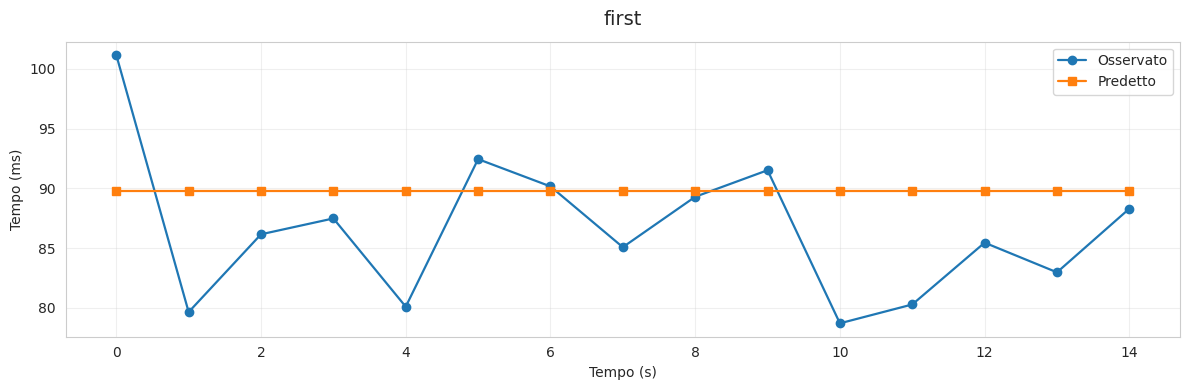

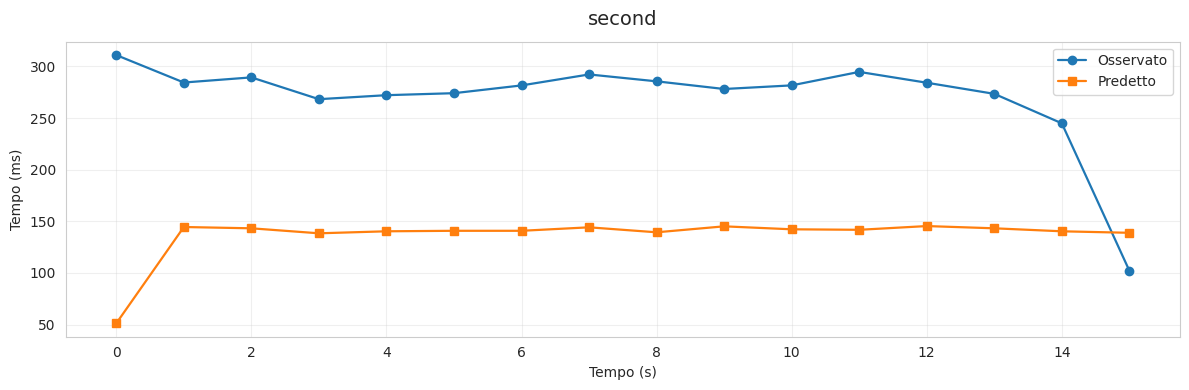

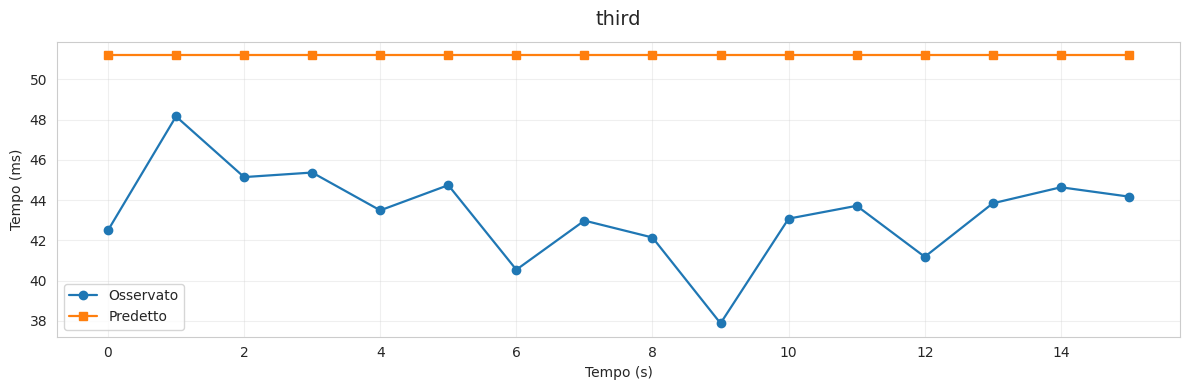

In [51]:
def create_user_load_prediction_comparison_2(requests_df: pd.DataFrame, performance_result: pd.DataFrame, time_tick_us: int = 1_000_000) -> pd.DataFrame:
    """
    Confronta l'andamento osservato con una predizione basata sulla formula T = L·X / R,
    usando finestre di 1 secondo.
    """

    # get the mean times from the data requests for each time_tick_us
    df = requests_df.copy()
    df['segment'] = df['scenario'] + ' • ' + df["service"] + ' • ' + df['service_name']
    df['start_bin_idx'] = (df['start_time_us'] // time_tick_us).astype(int)
    df['end_bin_idx'] = ((np.maximum(df['end_time_us'] - 1, df['start_time_us'])) // time_tick_us).astype(int)
    
    times = (
        df.groupby(['service_name', 'service', 'mu', 'start_bin_idx'])['metric_value']
          .mean().rename('observed_time_ms').reset_index()
    )
    times.rename(columns={"start_bin_idx": "bin_idx"}, inplace=True)
    times["time_s"] = times["bin_idx"] * (time_tick_us / 1_000_000.0)
    times["time_ms"] = times["time_s"] * 1000.0

    sampled_users = sample_users(df, time_tick_us)
    sampled_users["bin_idx"] = (sampled_users["timestamp"] // time_tick_us).astype(int)

    base_services = (
        df.groupby("service_name")
        .agg(
            service=("service", "first"),
            mu=("mu", "first"),
            cores=("cores", "first")
        )
        .reset_index()
    )
    base_services["cores"] = base_services["cores"].fillna(1).replace(0, 1).astype(int)
    base_services["mu"] = base_services["mu"].fillna(0)

    min_bin = int(df["start_bin_idx"].min())
    max_bin = int(df["end_bin_idx"].max())
    bin_indices = range(min_bin, max_bin + 1)

    if times.empty:
        raise ValueError("Impossibile calcolare tempi osservati per i bin selezionati.")

    observed_max = times["observed_time_ms"].max()
    if pd.isna(observed_max):
        observed_max = time_tick_ms

    predicted_records: list[dict[str, float]] = []
    for bin_idx in bin_indices:
        bin_users = (
            sampled_users[sampled_users["bin_idx"] == bin_idx]
            .groupby("service_name")["users"]
            .mean()
            .rename("mean_users")
            .reset_index()
        )

        mean_users_per_workflow = base_services.merge(bin_users, on="service_name", how="left")
        mean_users_per_workflow["mean_users"] = mean_users_per_workflow["mean_users"].fillna(0.0)

        for sn in mean_users_per_workflow["service_name"].unique():
            if sn == 'all':
                continue
            mean_users_per_workflow_sn = mean_users_per_workflow[mean_users_per_workflow["service_name"] == sn]
            theoretical_cdf = get_theoretical_cdf(
                "simple",
                mean_users_per_workflow_sn,
                performance_result,
                time_tick_ms,
                -1.
            )

            predicted_mean_ms = np.nan
            
            total = 0.0
            for v in theoretical_cdf:
                total = total + (1 - v) * time_tick_ms

            predicted_mean_ms = total

            predicted_records.append(
                {
                    "bin_idx": bin_idx,
                    #"scenario": mean_users_per_workflow_sn["scenario"].values[0],
                    "service_name": sn,
                    "service": mean_users_per_workflow_sn["service"].values[0],
                    "mu": mean_users_per_workflow_sn["mu"].values[0],
                    "time_s": bin_idx * (time_tick_us / 1_000_000.0),
                    "predicted_time_ms": predicted_mean_ms
                }
            )

    predicted_df = pd.DataFrame(predicted_records)
    predicted_df["predicted_time_ms"] = predicted_df["predicted_time_ms"].fillna(0)
    comparison = times.merge(predicted_df, on=["bin_idx", "time_s", "service_name", 'service', "mu"], how="left")
    comparison = comparison.sort_values(["service_name", "service", "time_s"]).reset_index(drop=True)

    for service_name, group in comparison.groupby("service_name", dropna=False):
        if group.empty:
            continue

        plt.figure(figsize=(12, 4))
        plt.plot(group["time_s"], group["observed_time_ms"], marker="o", linewidth=1.6, label="Osservato")
        if group["predicted_time_ms"].notna().any():
            plt.plot(group["time_s"], group["predicted_time_ms"], marker="s", linewidth=1.6, label="Predetto")
        plt.title(f"{service_name}", fontsize=14, pad=12)
        plt.xlabel("Tempo (s)")
        plt.ylabel("Tempo (ms)")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

create_user_load_prediction_comparison_2(test_result, performance_result)